## Índice

### 1. Introducción
- 1.1. Contexto del problema
- 1.2. Objetivo de negocio
- 1.3. Pregunta de investigación
- 1.4. Definición de la variable objetivo
- 1.5. Momento de predicción 

### 2. Carga de Datos
- 2.1. Librerias
- 2.2. Carga de dataset

### 3. Análisis Exploratorio de Datos (EDA)
- 3.1. Primera Inspección de datos
- 3.2. Análisis de valores faltantes
- 3.3. Análisis Univariado: variables numéricas
- 3.4. Análisis de variables categóricas

### 4. Preparación de los datos
- 4.1. Eliminación de columnas irrelevantes
- 4.2. Estandarización de tipos
- 4.3. Construcción del Target y Cohortes
- 4.4. Análisis Exploratorio del Target
- 4.5. Análisis Bivariado (Categóricas vs Target)
- 4.6. Análisis de Estacionalidad

### 5. Análisis Avanzado y Selección de Características
- 5.1. Análisis de Outliers Multivariado
- 5.2. Correlación (Pearson vs Spearman)
- 5.3. Ingeniería de Características

### 6. Modelado Predictivo
- 6.1. Definición de Modelos Base
- 6.2. Optimización de Hiperparámetros
- 6.3. Evaluación y Comparación de Modelos
- 6.4. Refinamiento del Modelo Campeón
- 6.5. Importancia de Características
- 6.6. Análisis de Residuos
- 6.7. Intervalos de Confianza

---

## 1. Introducción

### 1.1 Contexto del problema

La fábrica de confección registra información detallada de sus órdenes de producción, incluyendo tiempos de máquina, operarios asignados, materiales y características del diseño. Actualmente, la estimación de la duración de las órdenes se basa en promedios históricos o experiencia empírica, lo que puede llevar a ineficiencias en la programación de la planta y promesas de entrega inexactas.

El presente estudio se centra en analizar y modelar el **Tiempo Total de Procesamiento (`tiempo_total_min`)**, que incluye el tiempo en máquina, alistamiento, aplique y pulida. A diferencia de un enfoque puramente de "Lead Time" comercial (desde la orden hasta la entrega), este análisis pone el foco en la **eficiencia operativa y la duración técnica** de la manufactura una vez iniciada la labor.

**Alcance**
- **Unidad de análisis**: Orden de producción (nivel detalle).
- **Variable objetivo**: `tiempo_total_min` (suma de tiempos operativos en minutos).
- **Enfoque**: Modelado predictivo supervisado (Regresión).
- **Tecnologías**: Python, Pandas, Scikit-Learn, XGBoost, LightGBM, CatBoost.

**Relevancia**
- **Programación de Planta**: Estimar con precisión cuánto tiempo ocupará una máquina/operario una orden específica.
- **Identificación de Drivers**: Entender qué factores (Operario, Máquina, Material, Diseño) impactan más en la duración.
- **Detección de Anomalías**: Identificar órdenes con tiempos inusualmente altos o bajos.

### 1.2 Objetivo de negocio

**Objetivo principal**  
Desarrollar un modelo de Machine Learning capaz de estimar el **tiempo total de procesamiento (`tiempo_total_min`)** de una orden de producción, basándose en sus características técnicas (diseño, material) y operativas (recursos asignados), para optimizar la planificación de la capacidad.

**Objetivos específicos**
1. **Caracterización del Proceso**: Realizar un Análisis Exploratorio de Datos (EDA) profundo para entender la distribución de los tiempos y la calidad de la información.
2. **Limpieza y Preparación**: Estandarizar datos, tratar valores nulos (e.g., imputación de puntadas) y codificar variables categóricas de alta cardinalidad (Operario, Material).
3. **Modelado Predictivo**: Entrenar y comparar múltiples algoritmos de regresión (Lineales, Árboles, Ensambles) para minimizar el error de estimación.
4. **Optimización**: Ajustar los hiperparámetros de los modelos más prometedores (Random Forest, Extra Trees, Gradient Boosting) para maximizar el $R^2$ y minimizar el RMSE.

**Indicadores (KPIs) de éxito del modelo**
- **$R^2$ (Coeficiente de Determinación)**: Buscamos explicar la mayor varianza posible de los tiempos reales.
- **RMSE (Raíz del Error Cuadrático Medio)**: Medida del error promedio en minutos, penalizando grandes desvíos.
- **MAE (Error Absoluto Medio)**: Error promedio directo en minutos, fácil de interpretar para negocio.

### 1.3 Pregunta de investigación

**Pregunta central**  
¿Es posible predecir con precisión el tiempo total de ejecución de una orden de producción (`tiempo_total_min`) utilizando información disponible al momento de la programación (diseño, material, operario asignado), y cuáles son los algoritmos más efectivos para esta tarea?

**Subpreguntas específicas**
1. **Factores de Influencia**: ¿Qué peso tienen el **Operario** y la **Máquina** en la duración del proceso frente a las características intrínsecas del producto (Material, Puntadas)?
2. **Comparación de Modelos**: ¿Superan los modelos de ensamblaje (Random Forest, Extra Trees, Boosting) a los modelos lineales tradicionales en este contexto de datos industriales?
3. **Calidad de Datos**: ¿Cómo afecta la imputación de variables clave (como `Puntadas` o `CantidadBuena`) al desempeño del modelo?
4. **Incertidumbre**: ¿Podemos establecer intervalos de confianza fiables para nuestras predicciones de tiempo?

### 1.4 Definición de la variable objetivo

**Variable Objetivo: `tiempo_total_min`**

La variable a predecir es la suma de los tiempos parciales registrados durante la ejecución de la orden, expresada en **minutos**.

$$ \text{tiempo\_total\_min} = \text{TiempoenMaquina} + \text{TiempoAlistamiento} + \text{TiempoAplique} + \text{TiempoPulida} $$

*Nota: Los componentes originales vienen en formato `hh:mm:ss` o minutos, y son estandarizados a minutos numéricos durante la etapa de preparación.*

**Justificación**:
Esta variable representa el **consumo real de recursos** en la planta. Predecirla permite saber cuánto tiempo estará ocupada una estación de trabajo.

### 1.5 Momento de predicción y Variables

**Escenario de Predicción: Inicio de Producción / Programación**

El modelo asume que la predicción se realiza en el momento en que la orden ha sido **programada y asignada**, es decir, cuando ya se conocen los recursos que la ejecutarán.

**Variables Predictoras (Features) utilizadas en el notebook:**
- **Recursos Asignados**:
    - `Operario`: Quién realiza la labor (codificado con Target Encoding).
    - `NombreMaquina`: En qué equipo se procesa (codificado con Target Encoding).
    - `turno`: Mañana, Tarde o Noche (derivado de la hora de inicio).
- **Características del Producto/Material**:
    - `codigoMaterial`: Tipo de material (codificado con Target Encoding).
    - `PuntoPlantilla`: Especificación técnica del diseño (One-Hot Encoding).
- **Métricas de Volumen y Complejidad**:
    - `Puntadas`: Número de puntadas del diseño (imputado si es nulo).
    - `CantidadBuena`: Cantidad de unidades producidas (utilizada como proxy del volumen de la orden).
    - `puntadas_totales`: Feature de ingeniería (`Puntadas` $\times$ `CantidadBuena`).
- **Contexto Temporal**:
    - `dia_semana`, `mes`, `hora`: Derivados de `FechaInicio` para capturar estacionalidad operativa.

**Nota sobre Fuga de Información (Data Leakage)**:
El uso de `CantidadBuena` implica que el modelo conoce *a posteriori* cuántas unidades salieron buenas. En un entorno productivo real, esta variable debería sustituirse por `CantidadProgramada` u `Ordenada`. Sin embargo, para efectos de este análisis exploratorio y validación de capacidad predictiva técnica, se utiliza `CantidadBuena` como la mejor aproximación disponible del volumen real procesado.

---

## 2. Carga de Datos


### 2.1 Librerias

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as  sns
import re
from textwrap import fill,wrap
import itertools
import math



# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_palette("husl")

# Configuración de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Configuración reproducible
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)



### 2.2. Carga de dataset

In [37]:
df = pd.read_csv('data/produccion.csv')
df.head()


C:\Users\Santiago\AppData\Local\Temp\ipykernel_4572\1139538576.py:1: DtypeWarning: Columns (18,27,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/produccion.csv')


,Operario,PedidoId,NumeroOrden,MaterialIdOrden,TipoMaterialId,codigoMaterial,CantidadOrden,NombreMaquina,CantidadProgramada,FechaInicio,FechaFin,año,TiempoenMaquina,CantidadBuena,CantidadMala,CantidadReprocesada,MaterialId,Ubicacion,PuntoPlantilla,DisenosTPTG,InterlonId,HiloInferiorId,NumeroApliques,TiempoAlistamiento,TiempoMaquina,TiempoAplique,TiempoPulida,Velocidad,Puntadas,Plastico,MaquinaPlasticoId,TiempoQuitarPlastico,Canutillo,Chenille,Cordon,Presion,Temperatura,Unnamed: 37
0,Edward Dario Pulgarin Paniagua,5912,O11585,1625,28,U53554,241,Bordadora 12,241,2021-06-15 11:21:39.9748690,2021-06-15 17:41:58.7622990,2021,380.00,162,0,0,1625,NaN,1,NaN,NaN,91.00,0.00,NaN,NaN,NaN,NaN,NaN,1735.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Edward Dario Pulgarin Paniagua,5981,O11681,1625,28,U53554,544,Bordadora 12,544,2021-06-18 11:37:35.9040465,2021-06-23 06:47:54.1423484,2021,6910.00,471,0,0,1625,NaN,1,NaN,NaN,91.00,0.00,NaN,NaN,NaN,NaN,NaN,1735.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Edwin Alonso Jaramillo Castaño,5981,O11681,1625,28,U53554,544,Bordadora 12,544,2021-06-18 11:37:35.9040465,2021-06-23 06:47:54.1423484,2021,6910.00,5,0,0,1625,NaN,1,NaN,NaN,91.00,0.00,NaN,NaN,NaN,NaN,NaN,1735.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Francisco Nicolas Parra Acevedo,4225,O8269,1625,28,U53554,10,Bordadora 05,10,2021-03-08 10:38:09.8705291,2021-03-08 11:25:26.7423458,2021,47.00,10,0,0,1625,NaN,1,NaN,NaN,91.00,0.00,NaN,NaN,NaN,NaN,NaN,1735.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Gloria Elsy Jimenez Giraldo,831,O1339,1625,28,U53554,40,Bordadora 14,40,2020-07-07 21:00:57.3642183,2020-07-07 21:27:32.5160898,2020,27.00,13,0,0,1625,NaN,1,NaN,NaN,91.00,0.00,NaN,NaN,NaN,NaN,NaN,1735.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---

## 3. Análisis Exploratorio de Datos (EDA)

### 3.1. Primera Inspección de datos

In [38]:
# Inspección inicial y vista general del dataset

print("=" * 80)
print("INFORMACIÓN GENERAL DEL DATASET".center(80))
print("=" * 80)
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
print("Listado de columnas:", sorted(df.columns.tolist()))

# Primeras filas con formato visual para detectar patrones y problemas
display(df.head().style.background_gradient(cmap='coolwarm', subset=['TiempoenMaquina']))

print("\n" + "=" * 80)
print("ESTRUCTURA DE DATOS".center(80))
print("=" * 80)
df.info()

print("\n" + "=" * 80)
print("ESTADÍSTICAS DESCRIPTIVAS".center(80))
print("=" * 80)
display(df.describe().round(2).T)

print("\nTipos de datos por columna:")
display(df.dtypes.to_frame("dtype"))

print("\nMuestra aleatoria para revisión visual:")
display(df.sample(n=min(5, len(df))))

                        INFORMACIÓN GENERAL DEL DATASET                         
Filas: 55490 | Columnas: 38
Listado de columnas: ['CantidadBuena', 'CantidadMala', 'CantidadOrden', 'CantidadProgramada', 'CantidadReprocesada', 'Canutillo', 'Chenille', 'Cordon', 'DisenosTPTG', 'FechaFin', 'FechaInicio', 'HiloInferiorId', 'InterlonId', 'MaquinaPlasticoId', 'MaterialId', 'MaterialIdOrden', 'NombreMaquina', 'NumeroApliques', 'NumeroOrden', 'Operario', 'PedidoId', 'Plastico', 'Presion', 'Puntadas', 'PuntoPlantilla', 'Temperatura', 'TiempoAlistamiento', 'TiempoAplique', 'TiempoMaquina', 'TiempoPulida', 'TiempoQuitarPlastico', 'TiempoenMaquina', 'TipoMaterialId', 'Ubicacion', 'Unnamed: 37', 'Velocidad', 'año', 'codigoMaterial']


,Operario,PedidoId,NumeroOrden,MaterialIdOrden,TipoMaterialId,codigoMaterial,CantidadOrden,NombreMaquina,CantidadProgramada,FechaInicio,FechaFin,año,TiempoenMaquina,CantidadBuena,CantidadMala,CantidadReprocesada,MaterialId,Ubicacion,PuntoPlantilla,DisenosTPTG,InterlonId,HiloInferiorId,NumeroApliques,TiempoAlistamiento,TiempoMaquina,TiempoAplique,TiempoPulida,Velocidad,Puntadas,Plastico,MaquinaPlasticoId,TiempoQuitarPlastico,Canutillo,Chenille,Cordon,Presion,Temperatura,Unnamed: 37
0,Edward Dario Pulgarin Paniagua,5912,O11585,1625,28,U53554,241,Bordadora 12,241,2021-06-15 11:21:39.9748690,2021-06-15 17:41:58.7622990,2021,380.000000,162,0,0,1625,nan,1,nan,nan,91.000000,0.000000,nan,nan,nan,nan,nan,1735.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan
1,Edward Dario Pulgarin Paniagua,5981,O11681,1625,28,U53554,544,Bordadora 12,544,2021-06-18 11:37:35.9040465,2021-06-23 06:47:54.1423484,2021,6910.000000,471,0,0,1625,nan,1,nan,nan,91.000000,0.000000,nan,nan,nan,nan,nan,1735.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan
2,Edwin Alonso Jaramillo Castaño,5981,O11681,1625,28,U53554,544,Bordadora 12,544,2021-06-18 11:37:35.9040465,2021-06-23 06:47:54.1423484,2021,6910.000000,5,0,0,1625,nan,1,nan,nan,91.000000,0.000000,nan,nan,nan,nan,nan,1735.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan
3,Francisco Nicolas Parra Acevedo,4225,O8269,1625,28,U53554,10,Bordadora 05,10,2021-03-08 10:38:09.8705291,2021-03-08 11:25:26.7423458,2021,47.000000,10,0,0,1625,nan,1,nan,nan,91.000000,0.000000,nan,nan,nan,nan,nan,1735.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan
4,Gloria Elsy Jimenez Giraldo,831,O1339,1625,28,U53554,40,Bordadora 14,40,2020-07-07 21:00:57.3642183,2020-07-07 21:27:32.5160898,2020,27.000000,13,0,0,1625,nan,1,nan,nan,91.000000,0.000000,nan,nan,nan,nan,nan,1735.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan



                              ESTRUCTURA DE DATOS                               
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55490 entries, 0 to 55489
Data columns (total 38 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Operario              55490 non-null  object 
 1   PedidoId              55490 non-null  int64  
 2   NumeroOrden           55490 non-null  object 
 3   MaterialIdOrden       55490 non-null  int64  
 4   TipoMaterialId        55490 non-null  int64  
 5   codigoMaterial        55490 non-null  object 
 6   CantidadOrden         55490 non-null  int64  
 7   NombreMaquina         55490 non-null  object 
 8   CantidadProgramada    55490 non-null  int64  
 9   FechaInicio           55490 non-null  object 
 10  FechaFin              55302 non-null  object 
 11  año                   55490 non-null  int64  
 12  TiempoenMaquina       55302 non-null  float64
 13  CantidadBuena         55490 non-null  i

,count,mean,std,min,25%,50%,75%,max
PedidoId,55490.00,17893.18,9661.36,1.00,9888.00,18022.00,26492.00,33867.00
MaterialIdOrden,55490.00,20389.91,10063.80,1625.00,13717.00,19567.00,28518.00,40516.00
TipoMaterialId,55490.00,28.00,0.00,28.00,28.00,28.00,28.00,28.00
CantidadOrden,55490.00,778.04,1203.85,1.00,152.00,485.00,996.00,39591.00
CantidadProgramada,55490.00,670.25,917.44,-620.00,146.00,440.00,892.00,39591.00
año,55490.00,2022.75,1.56,2020.00,2022.00,2023.00,2024.00,2025.00
TiempoenMaquina,55302.00,587.79,1711.55,0.00,51.00,260.00,536.00,99215.00
CantidadBuena,55490.00,155.46,1255.28,0.00,25.00,80.00,188.00,286656.00
CantidadMala,55490.00,0.05,1.09,0.00,0.00,0.00,0.00,128.00
CantidadReprocesada,55490.00,0.07,3.19,0.00,0.00,0.00,0.00,335.00



Tipos de datos por columna:


,dtype
Operario,object
PedidoId,int64
NumeroOrden,object
MaterialIdOrden,int64
TipoMaterialId,int64
codigoMaterial,object
CantidadOrden,int64
NombreMaquina,object
CantidadProgramada,int64
FechaInicio,object



Muestra aleatoria para revisión visual:


,Operario,PedidoId,NumeroOrden,MaterialIdOrden,TipoMaterialId,codigoMaterial,CantidadOrden,NombreMaquina,CantidadProgramada,FechaInicio,FechaFin,año,TiempoenMaquina,CantidadBuena,CantidadMala,CantidadReprocesada,MaterialId,Ubicacion,PuntoPlantilla,DisenosTPTG,InterlonId,HiloInferiorId,NumeroApliques,TiempoAlistamiento,TiempoMaquina,TiempoAplique,TiempoPulida,Velocidad,Puntadas,Plastico,MaquinaPlasticoId,TiempoQuitarPlastico,Canutillo,Chenille,Cordon,Presion,Temperatura,Unnamed: 37
42335,Paola Katerine Rojas Marulanda,27103,O51935,29103,28,U85849,10,Muestras 02,10,2024-09-25 08:10:35.4724655,2024-09-25 08:10:42.2105706,2024,0.00,10,0,0,29103,NaN,0,NaN,NaN,91.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49093,Jhon Edihum Restrepo Montoya,29740,O56872,33543,28,U87901,1234,Bordadora 12,1234,2025-02-22 14:06:49.3914776,2025-02-22 18:29:19.8144592,2025,263.00,285,0,0,33543,NaN,0,NaN,NaN,91.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8690,Gloria Elsy Jimenez Giraldo,2353,O4734,10742,28,U78043,813,Bordadora 14,813,2020-10-29 18:08:56.3168133,2020-10-30 06:00:19.6162313,2020,712.00,167,0,0,10742,NaN,0,NaN,89.00,91.00,NaN,NaN,00:12:34.0000000,NaN,NaN,700,5949.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3955,Johan Stiven Perez Piedrahita,10519,O21070,2646,28,U74396,120,Bordadora 02,120,2022-01-29 12:52:21.5407492,2022-01-29 13:36:30.5495234,2022,44.00,6,0,0,2646,NaN,1,NaN,87.00,93.00,0.00,NaN,00:06:08.0000000,NaN,00:02:00.0000000,NaN,7957.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20391,Edilson De Jesus Zuleta Villegas,14294,O28026,16255,28,U68952,620,Bordadora 05,620,2022-08-11 07:45:56.9169408,2022-08-11 17:36:47.5936571,2022,591.00,130,0,0,16255,NaN,0,NaN,NaN,91.00,1.00,NaN,NaN,NaN,NaN,NaN,7744.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.2. Análisis de valores faltantes

In [39]:
metadata = {
    "Variable": [
        "Operario",
        "PedidoId",
        "NumeroOrden",
        "MaterialIdOrden",
        "codigoMaterial",
        "CantidadOrden",
        "NombreMaquina",
        "CantidadProgramada",
        "FechaInicio",
        "FechaFin",
        "año",
        "TiempoenMaquina",
        "CantidadBuena",
        "CantidadMala",
        "CantidadReprocesada",
        "MaterialId",
        "PuntoPlantilla",
        "HiloInferiorId",
        "TiempoAlistamiento",
        "TiempoMaquina",
        "TiempoAplique",
        "TiempoPulida",
        "Puntadas",
    ],
    "Tipo": [
        "Categórica",          # Operario
        "Numérica (ID)",       # PedidoId
        "Categórica",          # NumeroOrden
        "Numérica (ID)",       # MaterialIdOrden
        "Categórica",          # codigoMaterial
        "Numérica",            # CantidadOrden
        "Categórica",          # NombreMaquina
        "Numérica",            # CantidadProgramada
        "Fecha-Hora",          # FechaInicio
        "Fecha-Hora",          # FechaFin
        "Numérica",            # año
        "Numérica (Target)",   # TiempoenMaquina 🎯
        "Numérica",            # CantidadBuena
        "Numérica",            # CantidadMala
        "Numérica",            # CantidadReprocesada
        "Numérica (ID)",       # MaterialId
        "Categórica",          # PuntoPlantilla
        "Numérica (ID)",       # HiloInferiorId
        "Duración (texto)",    # TiempoAlistamiento
        "Duración (texto)",    # TiempoMaquina
        "Duración (texto)",    # TiempoAplique
        "Duración (texto)",    # TiempoPulida
        "Numérica",            # Puntadas
    ],
    "Descripción": [
        "Nombre del operario que ejecutó la orden",
        "Identificador del pedido en el sistema",
        "Código de la orden de producción",
        "ID del material asociado a la orden",
        "Código interno del material",
        "Cantidad solicitada en la orden (unidades)",
        "Nombre de la máquina donde se procesó la orden",
        "Cantidad programada en la máquina para la orden",
        "Fecha y hora de inicio del proceso en máquina",
        "Fecha y hora de fin del proceso en máquina",
        "Año calendario del registro",
        "Tiempo registrado en máquina (minutos)",
        "Cantidad de unidades buenas producidas",
        "Cantidad de unidades defectuosas producidas",
        "Cantidad de unidades reprocesadas",
        "ID del material final producido",
        "Referencia / punto de plantilla de bordado",
        "ID del hilo inferior utilizado",
        "Tiempo de alistamiento (formato hh:mm:ss)",
        "Tiempo de máquina detallado (formato hh:mm:ss)",
        "Tiempo de aplique (formato hh:mm:ss)",
        "Tiempo de pulida (formato hh:mm:ss)",
        "Número de puntadas asociadas a la orden",
    ],
    "Valores Faltantes": [
        df["Operario"].isna().sum(),
        df["PedidoId"].isna().sum(),
        df["NumeroOrden"].isna().sum(),
        df["MaterialIdOrden"].isna().sum(),
        df["codigoMaterial"].isna().sum(),
        df["CantidadOrden"].isna().sum(),
        df["NombreMaquina"].isna().sum(),
        df["CantidadProgramada"].isna().sum(),
        df["FechaInicio"].isna().sum(),
        df["FechaFin"].isna().sum(),
        df["año"].isna().sum(),
        df["TiempoenMaquina"].isna().sum(),
        df["CantidadBuena"].isna().sum(),
        df["CantidadMala"].isna().sum(),
        df["CantidadReprocesada"].isna().sum(),
        df["MaterialId"].isna().sum(),
        df["PuntoPlantilla"].isna().sum(),
        df["HiloInferiorId"].isna().sum(),
        df["TiempoAlistamiento"].isna().sum(),
        df["TiempoMaquina"].isna().sum(),
        df["TiempoAplique"].isna().sum(),
        df["TiempoPulida"].isna().sum(),
        df["Puntadas"].isna().sum(),
    ],
}

df_metadata = pd.DataFrame(metadata)

# Columna de porcentaje de valores faltantes
df_metadata["% Valores Faltantes"] = (
    df_metadata["Valores Faltantes"] / len(df) * 100
).round(2)

display(
    df_metadata.style
        .format({"% Valores Faltantes": "{:.2f}"})  # ⬅️ 2 decimales
        .applymap(
            lambda x: "background-color: #ffcccc" if x > 0 else "",
            subset=["Valores Faltantes", "% Valores Faltantes"]
        )
)

C:\Users\Santiago\AppData\Local\Temp\ipykernel_4572\1725962041.py:114: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(


,Variable,Tipo,Descripción,Valores Faltantes,% Valores Faltantes
0,Operario,Categórica,Nombre del operario que ejecutó la orden,0,0.00
1,PedidoId,Numérica (ID),Identificador del pedido en el sistema,0,0.00
2,NumeroOrden,Categórica,Código de la orden de producción,0,0.00
3,MaterialIdOrden,Numérica (ID),ID del material asociado a la orden,0,0.00
4,codigoMaterial,Categórica,Código interno del material,0,0.00
5,CantidadOrden,Numérica,Cantidad solicitada en la orden (unidades),0,0.00
6,NombreMaquina,Categórica,Nombre de la máquina donde se procesó la orden,0,0.00
7,CantidadProgramada,Numérica,Cantidad programada en la máquina para la orden,0,0.00
8,FechaInicio,Fecha-Hora,Fecha y hora de inicio del proceso en máquina,0,0.00
9,FechaFin,Fecha-Hora,Fecha y hora de fin del proceso en máquina,188,0.34


Porcentaje de valores faltantes por columna:


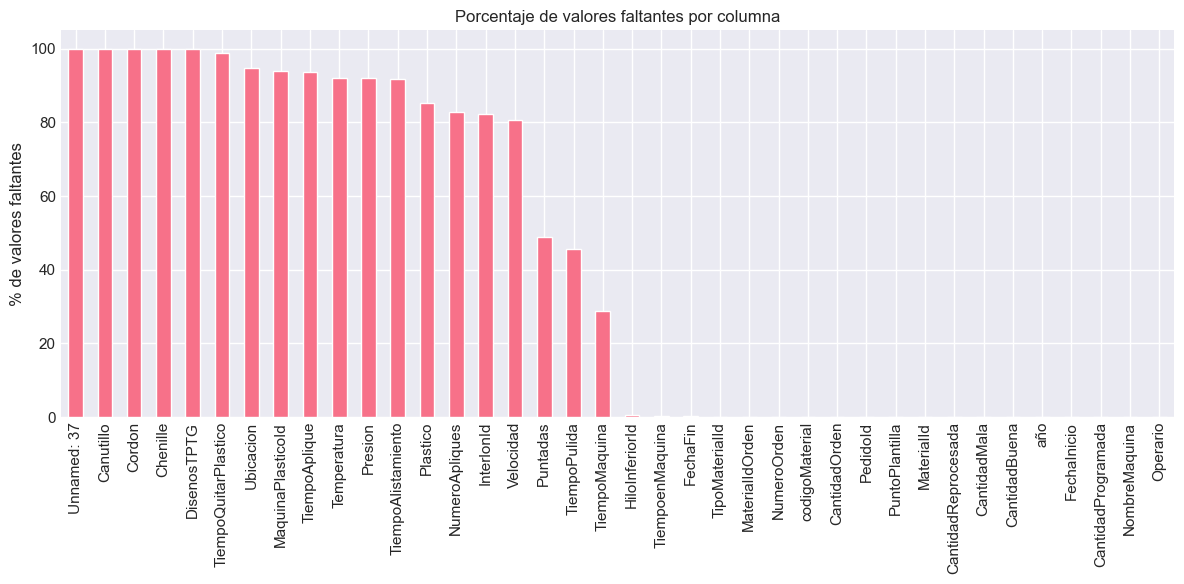

In [40]:
# Porcentaje de nulos por columna
missing_pct = df.isna().mean() * 100  # serie: columna → %
missing_pct = missing_pct.sort_values(ascending=False)

print("Porcentaje de valores faltantes por columna:")

# Gráfico de barras de nulos
plt.figure(figsize=(12, 6))
missing_pct.plot(kind="bar")
plt.ylabel("% de valores faltantes")
plt.title("Porcentaje de valores faltantes por columna")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 3.3. Análisis Univariado: variables númericas

In [41]:
num_cols_clave = [
    "TiempoenMaquina",
    "CantidadOrden",
    "CantidadProgramada",
    "CantidadBuena",
    "Puntadas",
]

# Filtramos solo las que realmente existan en el df (por si acaso)
num_cols_clave = [c for c in num_cols_clave if c in df.columns]
print("Variables numéricas clave para explorar:", num_cols_clave)

Variables numéricas clave para explorar: ['TiempoenMaquina', 'CantidadOrden', 'CantidadProgramada', 'CantidadBuena', 'Puntadas']


In [42]:
from scipy import stats

def plot_univariate_diagnostics(df, num_cols_clave, pclip=0.99):
    """
    Para cada columna en num_cols_clave dibuja:
      - Histograma (<= percentil pclip)
      - Boxplot (<= percentil pclip)
      - Q-Q plot contra normal (<= percentil pclip)
    """
    cols = [c for c in num_cols_clave if c in df.columns]

    for col in cols:
        # -----------------------------
        # 1) Datos base de la columna
        # -----------------------------
        data = df[col].dropna().astype(float)
        if data.empty:
            print(f"Columna '{col}' sin datos, se omite.")
            continue

        upper = data.quantile(pclip)
        data_clip = data[data <= upper]

        if data_clip.empty:
            print(f"Columna '{col}' quedó vacía después de recortar a p{int(pclip*100)}.")
            continue

        # -----------------------------
        # Figura con 3 subplots (2x2 pero usamos 3)
        # -----------------------------
        fig, axes = plt.subplots(2, 2, figsize=(10, 7))
        fig.suptitle(f"Análisis univariado de {col}", fontsize=14)

        # (1) Histograma
        ax_hist = axes[0, 0]
        ax_hist.hist(data_clip, bins=30)
        ax_hist.set_title(f"Histograma ({col} <= p{int(pclip*100)})")
        ax_hist.set_xlabel(col)
        ax_hist.set_ylabel("Frecuencia")

        # (2) Boxplot
        ax_box = axes[0, 1]
        ax_box.boxplot(data_clip, vert=True)
        ax_box.set_title(f"Boxplot ({col} <= p{int(pclip*100)})")
        ax_box.set_xticks([1])
        ax_box.set_xticklabels([col])

        # (3) Q-Q plot
        ax_qq = axes[1, 0]
        stats.probplot(data_clip, dist="norm", plot=ax_qq)
        ax_qq.set_title(f"Q-Q plot normal ({col} <= p{int(pclip*100)})")

        # Dejamos el último subplot vacío
        ax_empty = axes[1, 1]
        ax_empty.axis("off")

        plt.tight_layout(rect=[0, 0, 1, 0.99])
        plt.show()

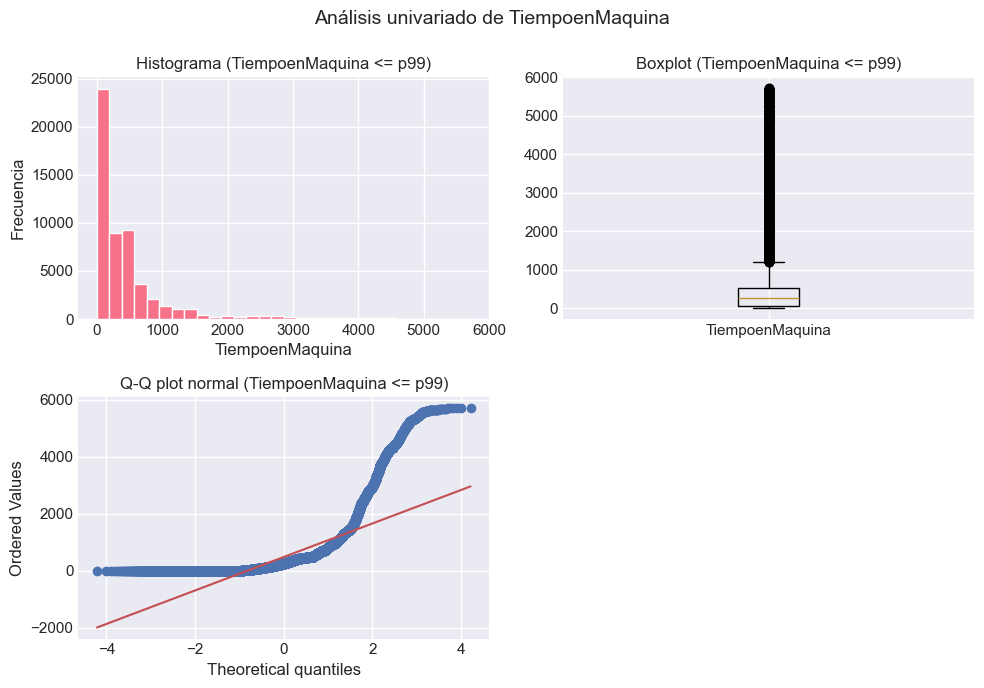

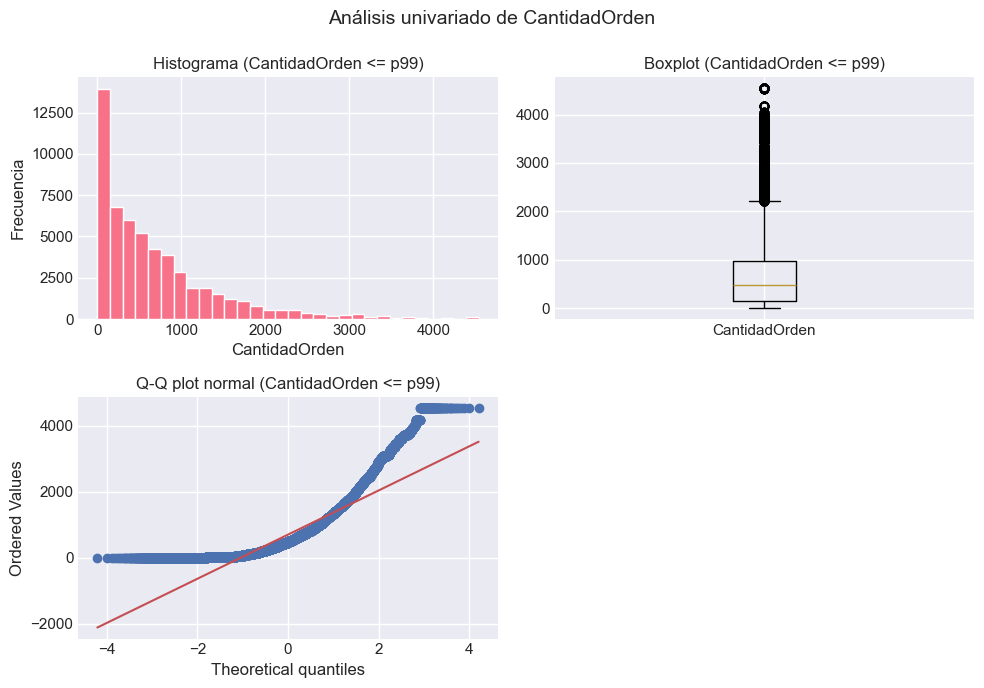

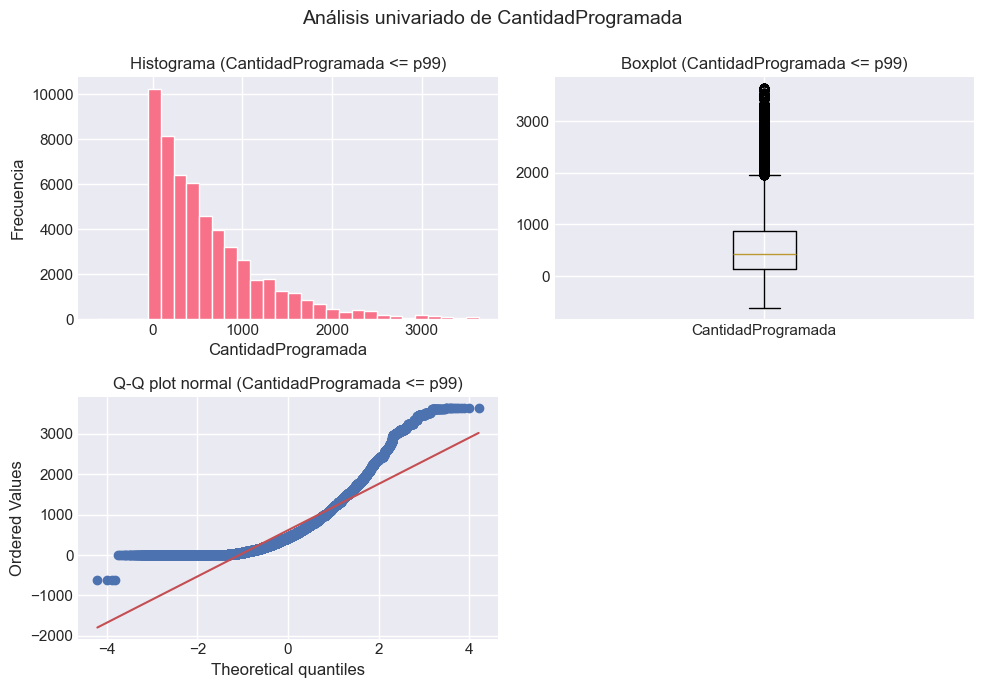

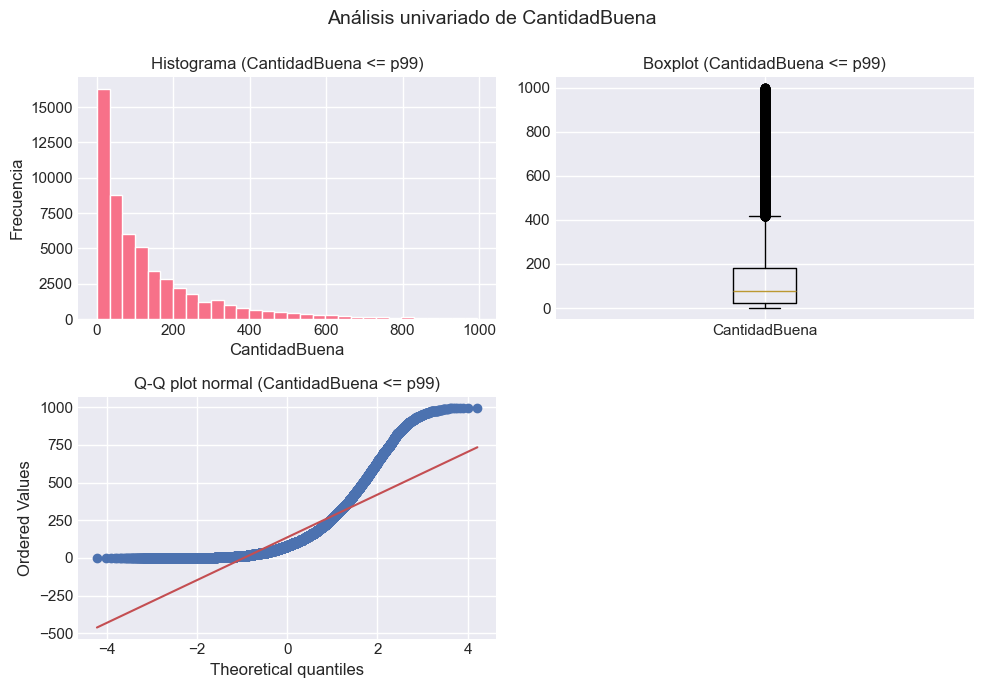

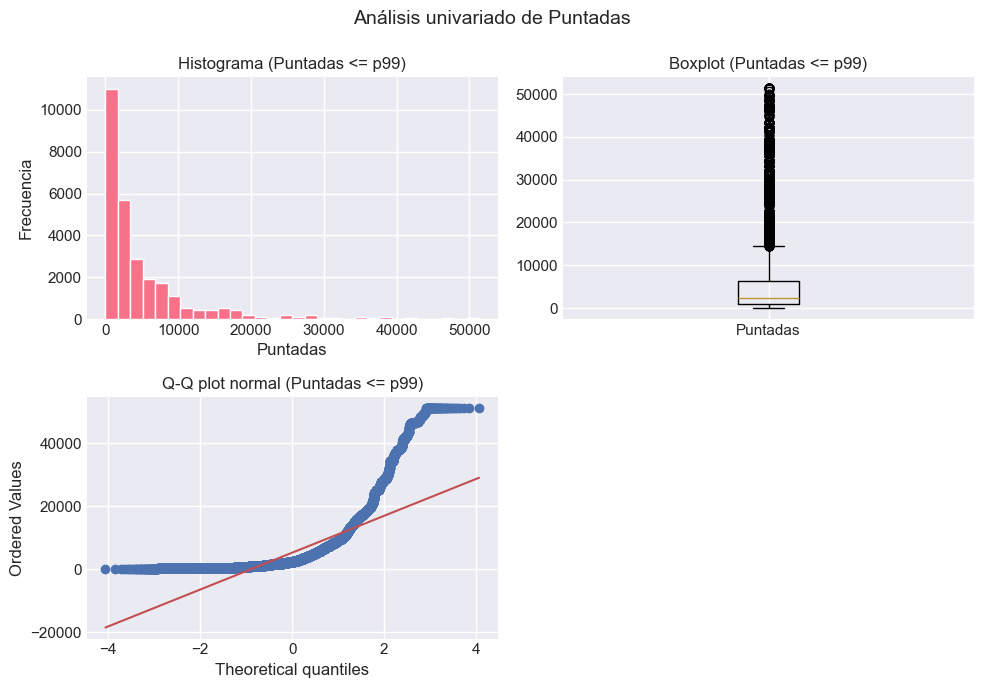

In [43]:
plot_univariate_diagnostics(df, num_cols_clave, pclip=0.99)

Eliminacion de columnas irrelevantes explicar

### 3.4. Análisis de variables categóricas

In [44]:
CAT_CONFIGS_PROD = [
    ("NombreMaquina", 10),
    ("Operario", 15),       # solo nombres, limpiados
    ("codigoMaterial", 10),
    ("dia_semana", None),
    ("turno", None),
]


def _agregar_dia_y_turno(data: pd.DataFrame) -> pd.DataFrame:
    """Deriva columnas dia_semana, hora y turno a partir de FechaInicio (si existe)."""
    data = data.copy()
    if "FechaInicio" in data.columns:
        data["FechaInicio_dt"] = pd.to_datetime(data["FechaInicio"], errors="coerce")
        data["dia_semana"] = data["FechaInicio_dt"].dt.day_name()
        data["hora"] = data["FechaInicio_dt"].dt.hour

        def clasificar_turno(h):
            if pd.isna(h):
                return np.nan
            if 6 <= h < 14:
                return "Mañana"
            elif 14 <= h < 22:
                return "Tarde"
            else:
                return "Noche"

        data["turno"] = data["hora"].apply(clasificar_turno)

    return data


# ==========================================================
# 1) FUNCIÓN SOLO DISTRIBUCIONES
# ==========================================================
def eda_categoricas_produccion_distribuciones(df: pd.DataFrame) -> None:
    """
    EDA de variables categóricas: SOLO distribuciones (barras + pie).

    NO depende del target, NO recibe target_col.
    """

    data = _agregar_dia_y_turno(df)

    for cat_col, top_n in CAT_CONFIGS_PROD:
        if cat_col not in data.columns:
            print(f"[INFO] Columna '{cat_col}' no existe en el DataFrame, se omite.")
            continue

        # Subconjunto solo con la categórica
        sub = data[[cat_col]].copy()

        # 1) Asegurar que la categórica esté como string limpio
        sub[cat_col] = sub[cat_col].astype(str).str.strip()

        # Limpieza especial SOLO para Operario: quedarnos solo con el primer nombre
        if cat_col == "Operario":
            sub[cat_col] = (
                sub[cat_col]
                .str.replace("nan", "", case=False)  # por si viene como texto "nan"
                .str.strip()
                .str.split()
                .str[0]  # primer token = primer nombre
            )

        # 2) Quitar nulos de la categórica
        sub = sub.replace("nan", np.nan)  # por si quedaron como texto "nan"
        sub = sub.dropna(subset=[cat_col])

        if sub.empty:
            print(f"[INFO] No hay datos válidos para {cat_col}, se omite.")
            continue

        # 3) Limitar a top_n categorías si aplica
        if top_n is not None:
            top_cats = sub[cat_col].value_counts().head(top_n).index
            sub = sub[sub[cat_col].isin(top_cats)]
            if sub.empty:
                print(
                    f"[INFO] Después de filtrar top categorías, {cat_col} quedó vacío, se omite."
                )
                continue

        print(f"\n=== Distribución categórica: {cat_col} ===")
        counts = sub[cat_col].value_counts()

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # ----- 1) Barras -----
        ax1 = axes[0]
        colors = plt.cm.Set3(range(len(counts)))
        x_pos = np.arange(len(counts))

        ax1.bar(x_pos, counts.values, color=colors)
        ax1.set_title(f"Distribución de {cat_col}")
        ax1.set_xlabel(cat_col)
        ax1.set_ylabel("Frecuencia")
        ax1.set_xticks(x_pos)
        ax1.set_xticklabels(counts.index, rotation=45, ha="right")

        total = len(sub)
        for i, (idx, val) in enumerate(counts.items()):
            ax1.text(
                i,
                val,
                f"{val}\n({val/total*100:.1f}%)",
                ha="center",
                va="bottom",
                fontsize=9,
            )

        # ----- 2) Pie chart -----
        ax2 = axes[1]
        ax2.pie(
            counts.values,
            labels=counts.index,
            autopct="%1.1f%%",
            colors=colors,
        )
        ax2.set_title(f"Proporción de {cat_col}")

        plt.suptitle(
            f"Distribución de variable categórica: {cat_col}",
            fontsize=14,
            fontweight="bold",
        )
        plt.tight_layout()
        plt.show()


=== Distribución categórica: NombreMaquina ===


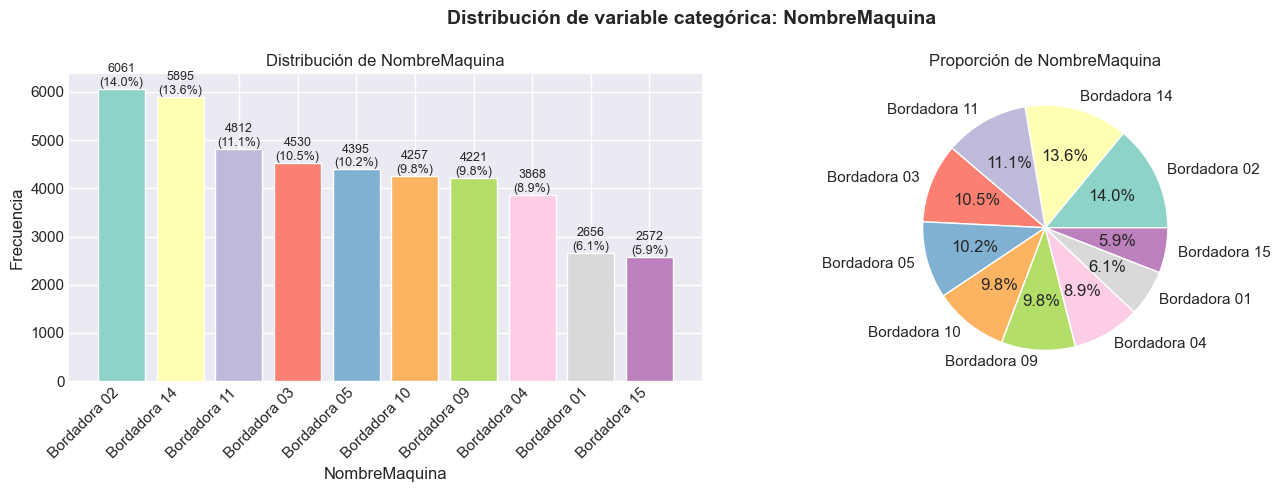


=== Distribución categórica: Operario ===


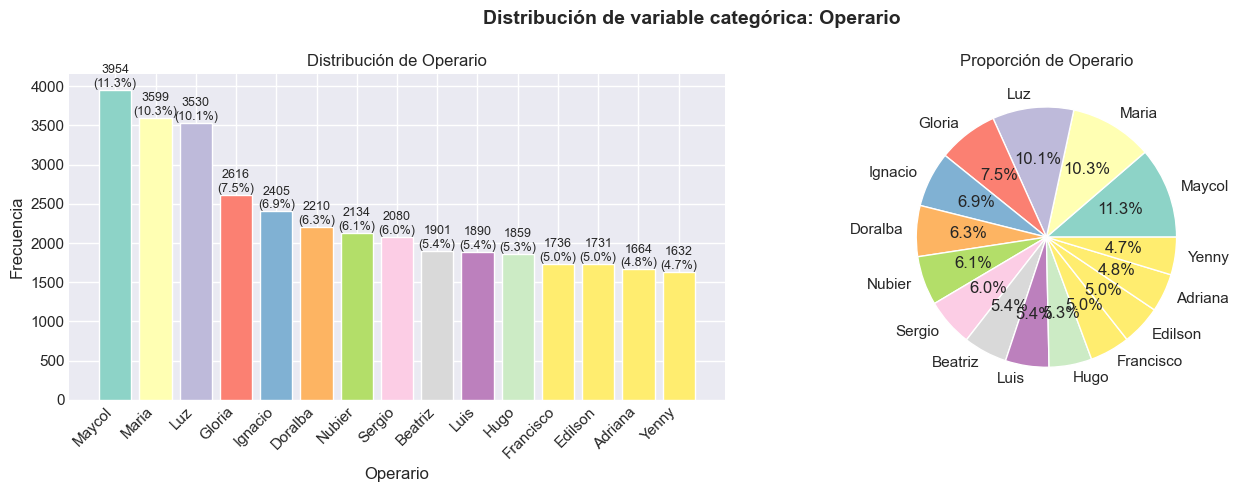


=== Distribución categórica: codigoMaterial ===


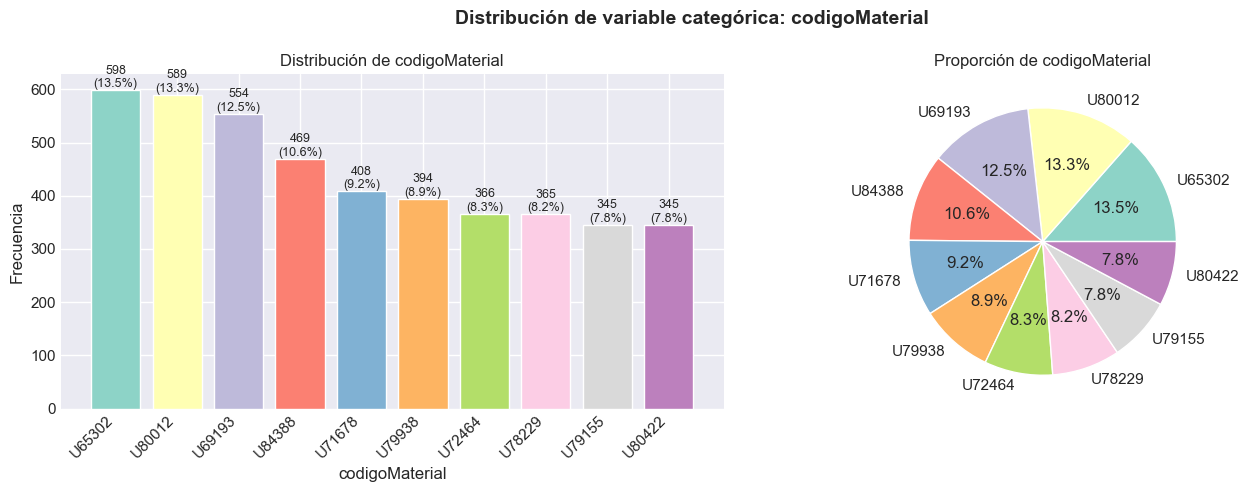


=== Distribución categórica: dia_semana ===


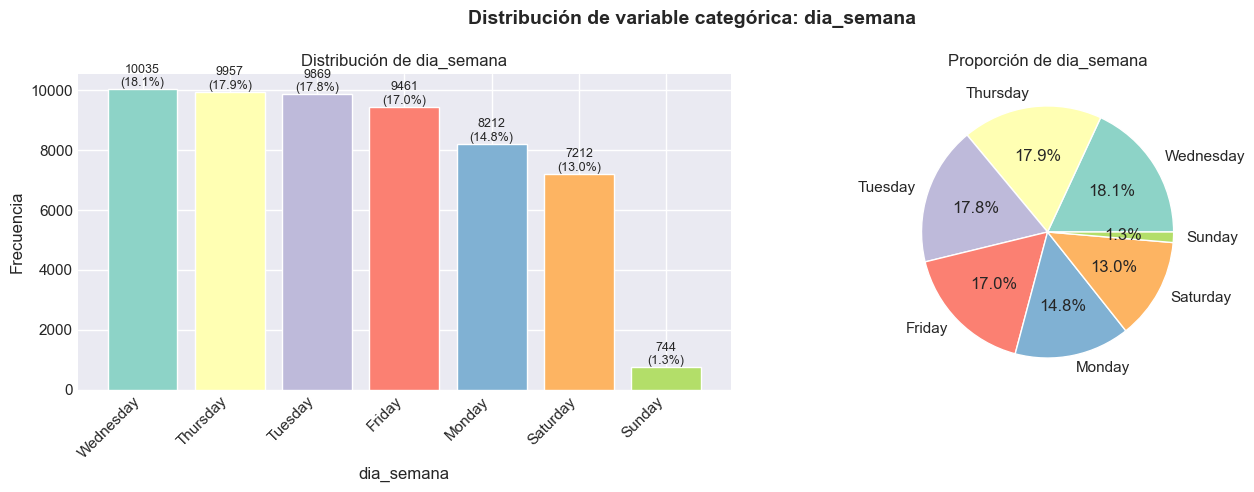


=== Distribución categórica: turno ===


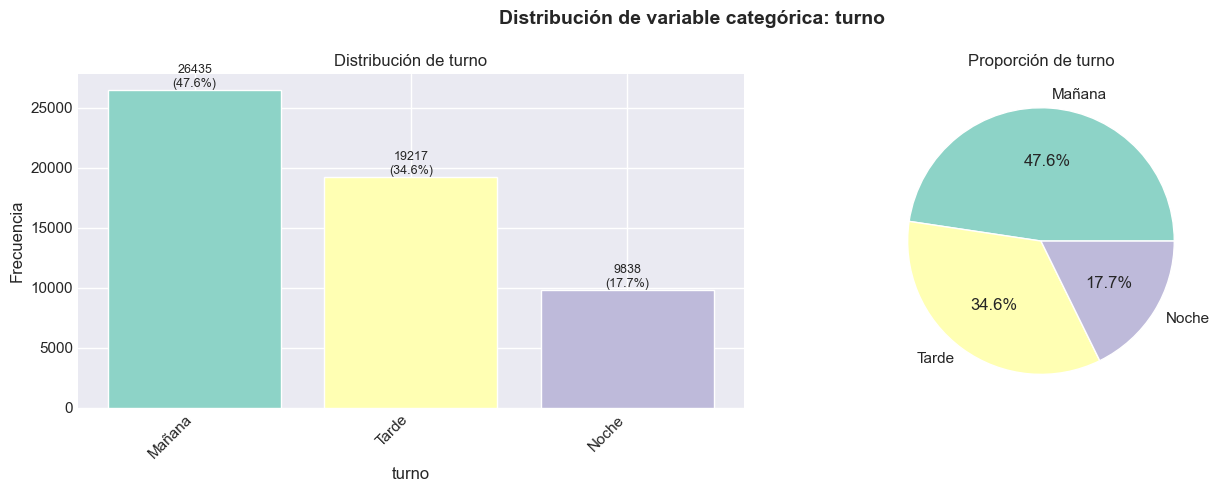

In [45]:
eda_categoricas_produccion_distribuciones(df)

---
## 4. Preparación de los datos

In [46]:
# Lista de columnas a eliminar
cols_to_drop = [
    "Plastico",
    "MaquinaPlasticoId",
    "TiempoQuitarPlastico",
    "Canutillo",
    "Chenille",
    "Cordon",
    "Presion",
    "Temperatura",
    "Unnamed: 37",
    "Velocidad",
    "NumeroApliques",
    "InterlonId",
    "DisenosTPTG",
    "Ubicacion",
    "TipoMaterialId",
    "MaterialId",
    "PedidoId",
    "NumeroOrden",

]

# Eliminarlas del dataframe
df = df.drop(columns=cols_to_drop, errors="ignore")

print("Columnas eliminadas:")
print(cols_to_drop)
print("\nNueva forma del dataset:", df.shape)
df


Columnas eliminadas:
['Plastico', 'MaquinaPlasticoId', 'TiempoQuitarPlastico', 'Canutillo', 'Chenille', 'Cordon', 'Presion', 'Temperatura', 'Unnamed: 37', 'Velocidad', 'NumeroApliques', 'InterlonId', 'DisenosTPTG', 'Ubicacion', 'TipoMaterialId', 'MaterialId', 'PedidoId', 'NumeroOrden']

Nueva forma del dataset: (55490, 20)


,Operario,MaterialIdOrden,codigoMaterial,CantidadOrden,NombreMaquina,CantidadProgramada,FechaInicio,FechaFin,año,TiempoenMaquina,CantidadBuena,CantidadMala,CantidadReprocesada,PuntoPlantilla,HiloInferiorId,TiempoAlistamiento,TiempoMaquina,TiempoAplique,TiempoPulida,Puntadas
0,Edward Dario Pulgarin Paniagua,1625,U53554,241,Bordadora 12,241,2021-06-15 11:21:39.9748690,2021-06-15 17:41:58.7622990,2021,380.00,162,0,0,1,91.00,NaN,NaN,NaN,NaN,1735.00
1,Edward Dario Pulgarin Paniagua,1625,U53554,544,Bordadora 12,544,2021-06-18 11:37:35.9040465,2021-06-23 06:47:54.1423484,2021,6910.00,471,0,0,1,91.00,NaN,NaN,NaN,NaN,1735.00
2,Edwin Alonso Jaramillo Castaño,1625,U53554,544,Bordadora 12,544,2021-06-18 11:37:35.9040465,2021-06-23 06:47:54.1423484,2021,6910.00,5,0,0,1,91.00,NaN,NaN,NaN,NaN,1735.00
3,Francisco Nicolas Parra Acevedo,1625,U53554,10,Bordadora 05,10,2021-03-08 10:38:09.8705291,2021-03-08 11:25:26.7423458,2021,47.00,10,0,0,1,91.00,NaN,NaN,NaN,NaN,1735.00
4,Gloria Elsy Jimenez Giraldo,1625,U53554,40,Bordadora 14,40,2020-07-07 21:00:57.3642183,2020-07-07 21:27:32.5160898,2020,27.00,13,0,0,1,91.00,NaN,NaN,NaN,NaN,1735.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55485,Doralba Maria Amariles Madrigal,40425,U90747,40,Bordadora 06,40,2025-10-08 15:09:29.0006427,2025-10-08 15:42:10.1142210,2025,33.00,6,0,0,0,91.00,NaN,NaN,NaN,NaN,NaN
55486,Ignacio Aristizabal Borja,40425,U90747,40,Bordadora 06,40,2025-10-09 12:10:16.3000934,2025-10-10 08:13:03.5795825,2025,1203.00,34,0,0,0,91.00,NaN,NaN,NaN,NaN,NaN
55487,Doralba Maria Amariles Madrigal,40434,U90750,20,Bordadora 06,20,2025-10-14 14:09:02.7085376,2025-10-14 14:52:30.6080336,2025,43.00,20,0,0,0,91.00,NaN,00:08:43.0000000,NaN,NaN,NaN
55488,Iliana Del Carmen Gonzalez Duran,40516,U90774,185,Bordadora 17,185,2025-10-10 03:07:43.5148904,2025-10-10 04:23:33.3393816,2025,76.00,17,0,0,0,91.00,NaN,NaN,NaN,NaN,NaN


### 4.1. Estandarización de tipos (fechas, numéricas, categóricas)

El objetivo de esta etapa es garantizar que las principales variables del dataset estén representadas con los tipos de datos adecuados para su posterior análisis y modelado. Se aplican las siguientes reglas:

- **Fechas** → convertir a `datetime`, permitiendo valores faltantes.
- **Variables categóricas** → convertir a `category` para optimizar memoria y facilitar análisis estadístico.
- **Identificadores** → mantener como `string` para evitar pérdidas de formato (por ejemplo, ceros a la izquierda).


In [47]:
df_raw = df.copy()

# --- Conversión de fechas ---
fecha_cols = [ "FechaInicio", "FechaFin"]
for col in fecha_cols:
    if col in df_raw.columns:
        df_raw[col] = pd.to_datetime(df_raw[col], errors="coerce")

# --- Conversión a categorías (ajustable según el diccionario de variables) ---
cat_cols = [
     "Operario", "NombreMaquina"
]
for col in cat_cols:
    if col in df_raw.columns:
        df_raw[col] = df_raw[col].astype("category")

# --- Identificadores → conservar como texto para evitar distorsiones numéricas ---
id_cols = [
    "PedidoId", "NumeroPedido",
    "NumeroOrden", "codigoMaterial",
    "MaterialIdOrden", "MaterialId",
]
for col in id_cols:
    if col in df_raw.columns:
        df_raw[col] = df_raw[col].astype(str)

# --- Validación posterior ---
print("Tipos de datos después de estandarización:")
display(df_raw.dtypes.to_frame("dtype").T)  # Vista compacta


Tipos de datos después de estandarización:


,Operario,MaterialIdOrden,codigoMaterial,CantidadOrden,NombreMaquina,CantidadProgramada,FechaInicio,FechaFin,año,TiempoenMaquina,CantidadBuena,CantidadMala,CantidadReprocesada,PuntoPlantilla,HiloInferiorId,TiempoAlistamiento,TiempoMaquina,TiempoAplique,TiempoPulida,Puntadas
dtype,category,object,object,int64,category,int64,datetime64[ns],datetime64[ns],int64,float64,int64,int64,int64,object,float64,object,object,object,object,float64


---

### 4.2. Construcción del Target y Cohortes (editar)

**4.2.1. Cálculo de `lead_time_total_horas` y `cycle_time_horas`**  
Se define la variable objetivo como la duración total entre `FechaIngreso` y `FechaFin` (en horas). De forma complementaria, `cycle_time_horas` mide la duración entre `FechaInicio` y `FechaFin` (útil para diagnóstico interno). Se corrigen valores negativos y se filtran outliers extremos.

In [48]:
# Partimos del df_raw original
df_std = df_raw.copy()

# 1) Convertir columnas de formato "hh:mm:ss.0000000" a minutos
cols_hhmm = ["TiempoAlistamiento", "TiempoMaquina", "TiempoAplique", "TiempoPulida"]

for c in cols_hhmm:
    if c in df_std.columns:
        df_std[c + "_min"] = (
            pd.to_timedelta(df_std[c], errors="coerce")
              .dt.total_seconds() / 60
        )

# 2) TiempoenMaquina ya está en minutos, no hay que convertirlo
# Creamos el total en minutos usando fillna(0) SOLO para la suma
df_std["tiempo_total_min"] = (
    df_std["TiempoenMaquina"].fillna(0)
    + df_std.get("TiempoAlistamiento_min", 0).fillna(0)
    + df_std.get("TiempoMaquina_min", 0).fillna(0)
    + df_std.get("TiempoAplique_min", 0).fillna(0)
    + df_std.get("TiempoPulida_min", 0).fillna(0)
)

# 3) Filtrar filas para modelado:
#    SOLO eliminamos filas donde TIEMPOENMAQUINA está vacío (NaN)
mask_sin_target = df_std["TiempoenMaquina"].isna()

print("Filas con TiempoenMaquina vacío (sin target):", mask_sin_target.sum())

# Dataset para modelado: solo filas que SÍ tienen TiempoenMaquina
df_model = df_std.loc[~mask_sin_target].copy()

print("Shape df_std (completo):", df_std.shape)
print("Shape df_model (para modelo):", df_model.shape)

# Vista rápida para verificar
cols_vista = [
    "TiempoenMaquina",
    "TiempoAlistamiento", "TiempoAlistamiento_min",
    "TiempoMaquina", "TiempoMaquina_min",
    "TiempoAplique", "TiempoAplique_min",
    "TiempoPulida", "TiempoPulida_min",
    "tiempo_total_min",
]
display(df_model[cols_vista].head(10))


Filas con TiempoenMaquina vacío (sin target): 188
Shape df_std (completo): (55490, 25)
Shape df_model (para modelo): (55302, 25)


,TiempoenMaquina,TiempoAlistamiento,TiempoAlistamiento_min,TiempoMaquina,TiempoMaquina_min,TiempoAplique,TiempoAplique_min,TiempoPulida,TiempoPulida_min,tiempo_total_min
0,380.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,380.00
1,6910.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6910.00
2,6910.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6910.00
3,47.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.00
4,27.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.00
5,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00
6,38.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.00
7,127.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,127.00
8,280.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,280.00
9,117.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117.00


### Análisis Exploratorio para variable objetivo

In [49]:
def eda_target_tiempo_total(
    df: pd.DataFrame,
    target_col: str = "tiempo_total_min",
    max_percentile_plot: float = 0.95
) -> None:
    """
    EDA detallado del target de tiempo (por defecto 'tiempo_total_min').

    Hace:
      1) Limpieza básica y conversión a numérico.
      2) Estadísticos descriptivos (media, mediana, cuartiles, colas, etc.).
      3) Información sobre ceros, negativos y NaNs.
      4) Histogramas + KDE en escala original y limitada (p.ej. hasta p99).
      5) Boxplot (original y limitado).
      6) Distribución en escala logarítmica (log1p).
      7) QQ-plot vs Normal para ver qué tan normal es la distribución.
    """

    if target_col not in df.columns:
        raise ValueError(f"La columna '{target_col}' no existe en el DataFrame.")

    # =========================
    # 1) Serie limpia del target
    # =========================
    y_raw = df[target_col]
    y = pd.to_numeric(y_raw, errors="coerce")

    print("=" * 80)
    print(f"EDA del target: {target_col}")
    print("=" * 80)
    print(f"Total filas en df         : {len(df)}")
    print(f"Valores válidos (numéricos): {y.notna().sum()}")
    print(f"Valores NaN                : {y.isna().sum()}")

    # Quitar NaNs para cálculos
    y_clean = y.dropna()

    # =========================
    # 2) Info básica de signo
    # =========================
    n_negativos = (y_clean < 0).sum()
    n_ceros = (y_clean == 0).sum()

    print("\n--- Signo de los valores ---")
    print(f"Valores negativos : {n_negativos} "
          f"({n_negativos / len(y_clean) * 100:.2f}%)")
    print(f"Valores iguales a 0: {n_ceros} "
          f"({n_ceros / len(y_clean) * 100:.2f}%)")
    print(f"Valores > 0        : {(y_clean > 0).sum()} "
          f"({(y_clean > 0).sum() / len(y_clean) * 100:.2f}%)")

    # =========================
    # 3) Estadísticos descriptivos
    # =========================
    quantiles = y_clean.quantile(
        [0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1.0]
    )

    print("\n--- Estadísticos descriptivos ---")
    print(f"Media       : {y_clean.mean():.3f}")
    print(f"Mediana     : {y_clean.median():.3f}")
    print(f"Desv. Est.  : {y_clean.std():.3f}")
    print(f"Mínimo      : {y_clean.min():.3f}")
    print(f"Máximo      : {y_clean.max():.3f}")
    print(f"Skewness    : {y_clean.skew():.3f}")   # asimetría
    print(f"Kurtosis    : {y_clean.kurt():.3f}")  # cola pesada

    print("\nCuantiles clave:")
    for q, v in quantiles.items():
        print(f"  P{int(q*100):>2}: {v:.3f}")

    # Percentil máximo para recortar outliers en gráficas
    p_max = y_clean.quantile(max_percentile_plot)

    # =========================
    # 4) Histogramas y boxplots
    # =========================
    sns.set(style="whitegrid")

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    ax1, ax2, ax3, ax4 = axes.flatten()

    # 4.1 Histograma + KDE en escala original (completa)
    sns.histplot(y_clean, kde=True, ax=ax1)
    ax1.set_title(f"Distribución completa de {target_col}")
    ax1.set_xlabel(f"{target_col}")
    ax1.set_ylabel("Frecuencia")

    # 4.2 Histograma + KDE recortado hasta p99 (o max_percentile_plot)
    sns.histplot(y_clean[y_clean <= p_max], kde=True, ax=ax2)
    ax2.set_title(f"Distribución recortada (≤ P{int(max_percentile_plot*100)})")
    ax2.set_xlabel(f"{target_col} (recortado)")
    ax2.set_ylabel("Frecuencia")

    # 4.3 Boxplot completo con límite en eje X para que se vea algo
    sns.boxplot(x=y_clean, ax=ax3)
    ax3.set_title(f"Boxplot de {target_col} (limitado a P{int(max_percentile_plot*100)})")
    ax3.set_xlabel(f"{target_col}")
    ax3.set_xlim(y_clean.min(), p_max)

    # 4.4 Boxplot recortado (solo puntos ≤ p99)
    sns.boxplot(x=y_clean[y_clean <= p_max], ax=ax4)
    ax4.set_title(f"Boxplot recortado (≤ P{int(max_percentile_plot*100)})")
    ax4.set_xlabel(f"{target_col} (recortado)")

    plt.tight_layout()
    plt.show()

    # =========================
    # 5) Distribución en log (solo valores > 0)
    # =========================
    y_pos = y_clean[y_clean > 0]
    if len(y_pos) > 0:
        y_log = np.log1p(y_pos)

        fig, ax = plt.subplots(figsize=(8, 5))
        sns.histplot(y_log, kde=True, ax=ax)
        ax.set_title(f"Distribución log1p({target_col}) (solo > 0)")
        ax.set_xlabel(f"log1p({target_col})")
        ax.set_ylabel("Frecuencia")
        plt.tight_layout()
        plt.show()
    else:
        print("\n[INFO] No hay valores positivos para analizar en escala logarítmica.")

    # =========================
    # 6) QQ-plot vs Normal
    # =========================
    fig, ax = plt.subplots(figsize=(6, 6))
    stats.probplot(y_clean, dist="norm", plot=ax)
    ax.set_title(f"QQ-plot de {target_col} vs Normal")
    plt.tight_layout()
    plt.show()

    # =========================
    # 7) Top valores más grandes (potenciales outliers)
    # =========================
    print("\n--- Top 10 valores más grandes (posibles outliers) ---")
    display(y_clean.sort_values(ascending=False).head(10).to_frame(name=target_col))

EDA del target: tiempo_total_min
Total filas en df         : 55302
Valores válidos (numéricos): 55302
Valores NaN                : 0

--- Signo de los valores ---
Valores negativos : 0 (0.00%)
Valores iguales a 0: 2273 (4.11%)
Valores > 0        : 53029 (95.89%)

--- Estadísticos descriptivos ---
Media       : 598.202
Mediana     : 269.667
Desv. Est.  : 1712.324
Mínimo      : 0.000
Máximo      : 99217.233
Skewness    : 25.288
Kurtosis    : 1125.823

Cuantiles clave:
  P 0: 0.000
  P 1: 0.000
  P 5: 0.500
  P25: 61.000
  P50: 269.667
  P75: 552.025
  P95: 2356.071
  P99: 5750.017
  P100: 99217.233


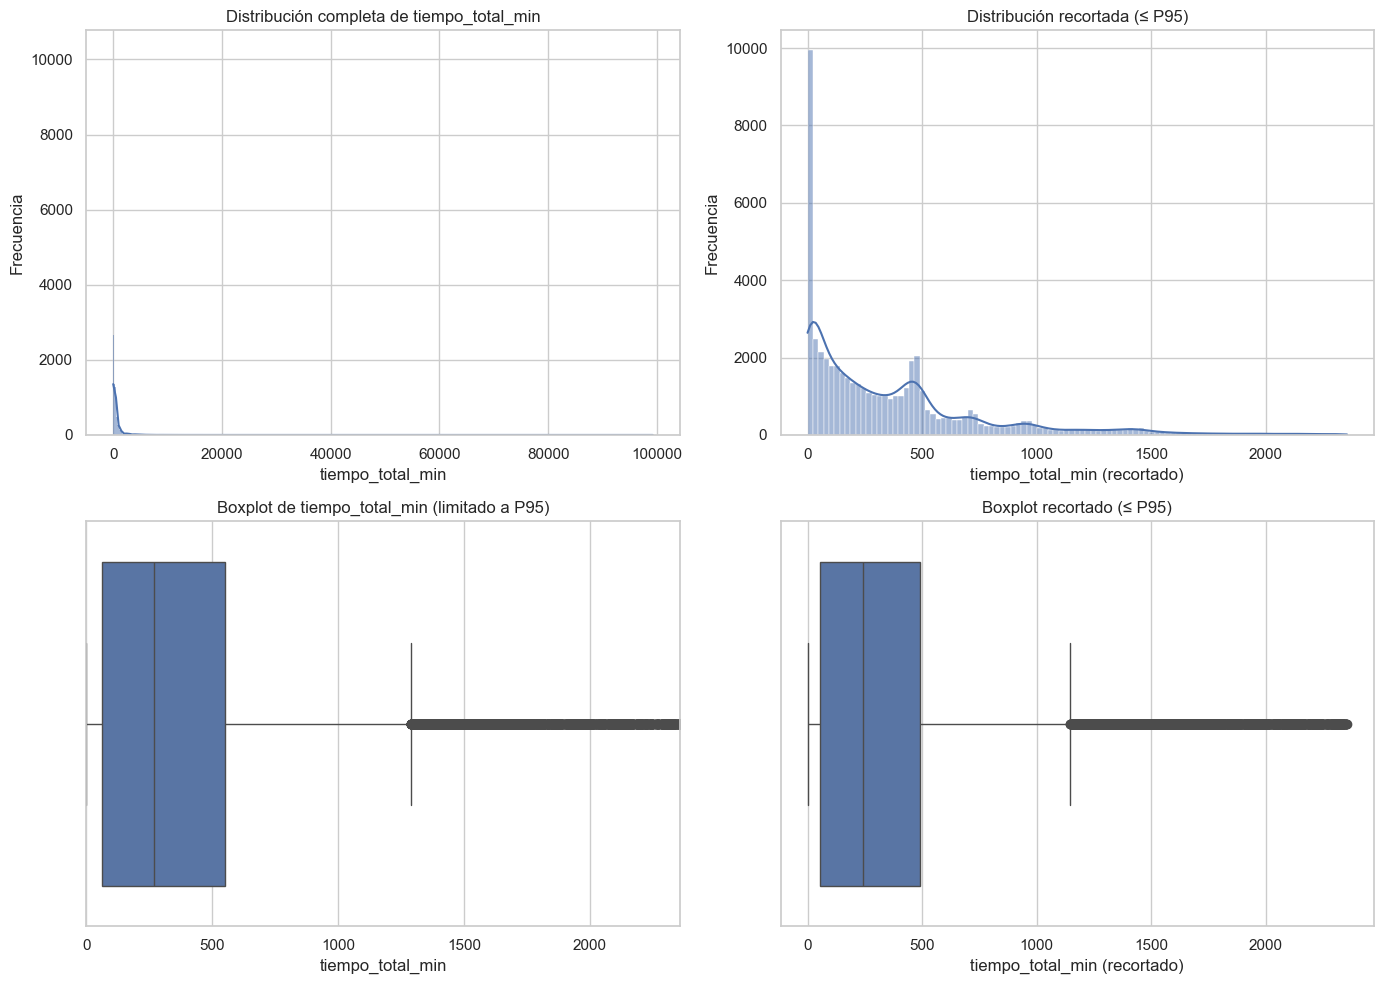

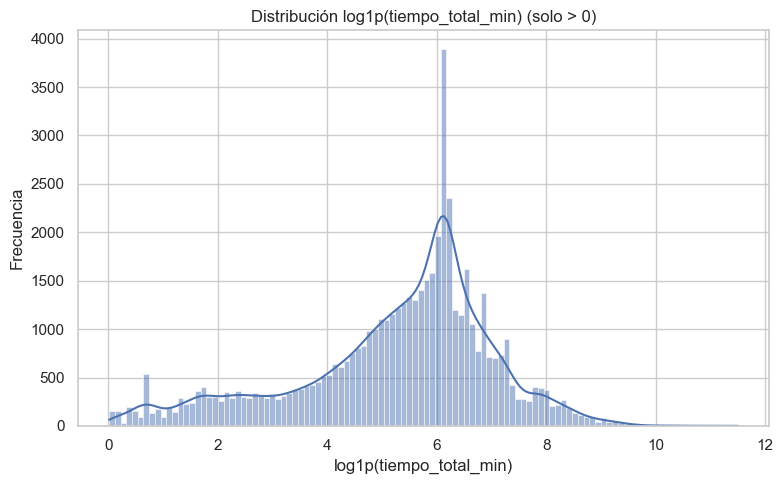

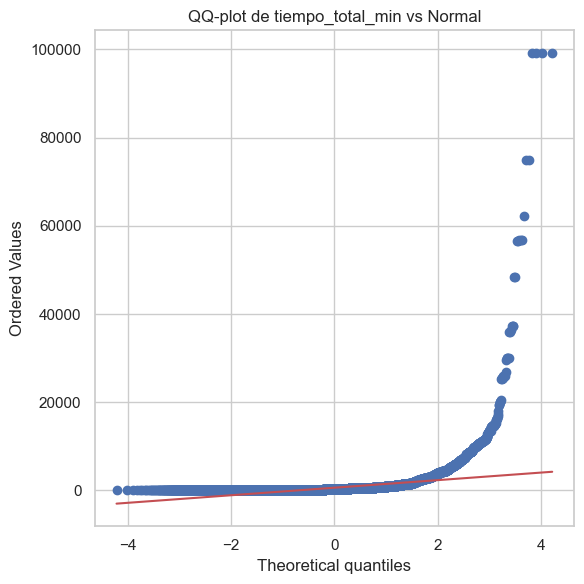


--- Top 10 valores más grandes (posibles outliers) ---


,tiempo_total_min
20966,99217.23
20967,99217.23
20972,99217.23
20979,99217.23
5492,74935.17
5491,74935.17
6362,62214.00
19525,56891.25
19509,56891.25
19515,56891.25


In [50]:
eda_target_tiempo_total(df_model, target_col="tiempo_total_min")

In [51]:
def plot_scatter_vs_target(df, num_cols_clave, target_col="tiempo_total_min", pclip=0.99):
    """
    Para cada columna en num_cols_clave dibuja SOLO:
      - Scatter vs target_col (<= percentil pclip en x e y)
    """
    cols = [c for c in num_cols_clave if c in df.columns]

    if target_col not in df.columns:
        print(f"❌ La columna target '{target_col}' no existe en el DataFrame.")
        return

    for col in cols:
        # No tiene sentido scatter de target contra sí mismo
        if col == target_col:
            print(f"Columna '{col}' es el target, se omite scatter.")
            continue

        # Quitamos nulos en ambas columnas
        data_scatter = df[[col, target_col]].dropna().astype(float)

        if data_scatter.empty:
            print(f"Sin datos para scatter entre '{col}' y '{target_col}'.")
            continue

        x = data_scatter[col].values
        y = data_scatter[target_col].values

        # Recorte a pclip en ambas variables
        x_max = np.quantile(x, pclip)
        y_max = np.quantile(y, pclip)
        mask = (x <= x_max) & (y <= y_max)

        x_clip_s = x[mask]
        y_clip_s = y[mask]

        if x_clip_s.size == 0:
            print(f"Scatter '{col}' vs '{target_col}' quedó vacío después de recortar.")
            continue

        plt.figure(figsize=(6, 4))
        plt.scatter(x_clip_s, y_clip_s, s=5, alpha=0.5)
        plt.xlabel(col)
        plt.ylabel(target_col)
        plt.title(f"{target_col} vs {col}\n(<= p{int(pclip*100)} en ambas)")
        plt.tight_layout()
        plt.show()

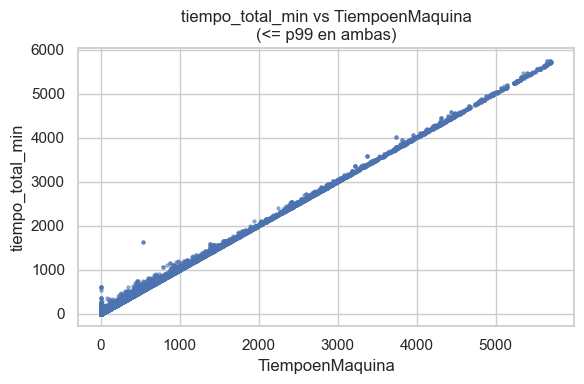

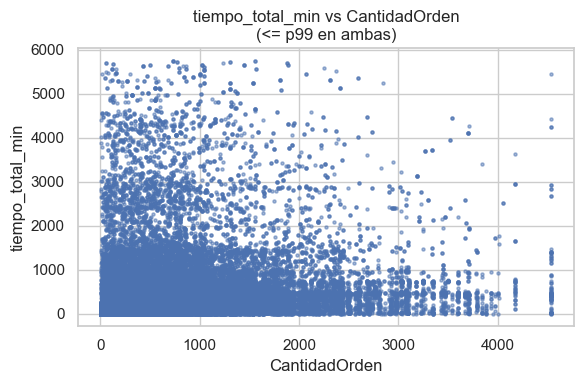

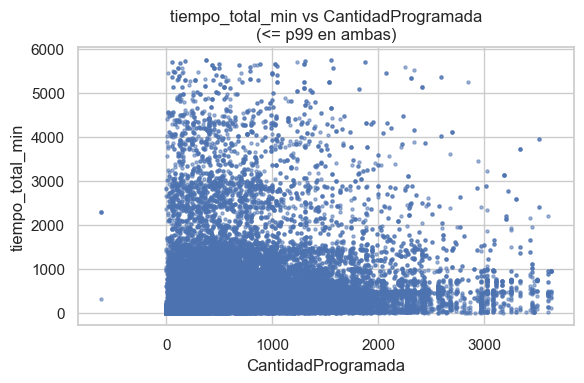

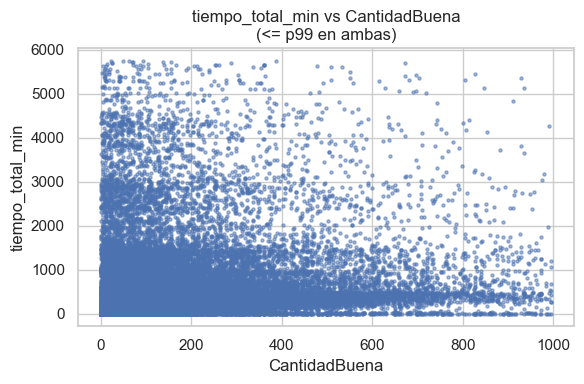

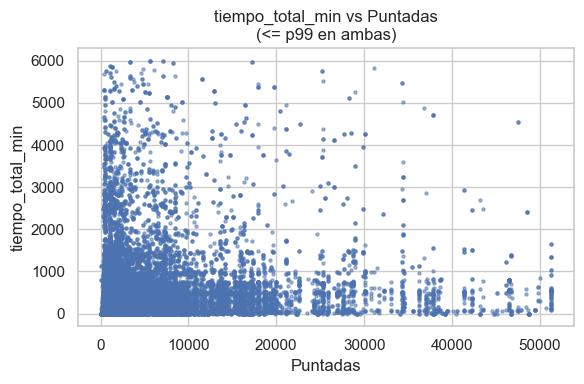

In [52]:
plot_scatter_vs_target(df_model, num_cols_clave, target_col="tiempo_total_min", pclip=0.99)

### Análisis de variables categóricas

In [53]:
def eda_categoricas_produccion_vs_target(
    df: pd.DataFrame, target_col: str = "tiempo_total_min"
) -> None:
    """
    EDA de variables categóricas vs target.

    Genera, para cada categórica:
      - Boxplot del target por categoría
      - Tabla de stats (N, media, mediana, desv.est.)

    AQUÍ SÍ se usa y se requiere el parámetro target_col.
    """

    data = _agregar_dia_y_turno(df)

    if target_col not in data.columns:
        print(f"[ERROR] La columna target '{target_col}' no existe en el DataFrame.")
        return

    for cat_col, top_n in CAT_CONFIGS_PROD:
        if cat_col not in data.columns:
            print(f"[INFO] Columna '{cat_col}' no existe en el DataFrame, se omite.")
            continue

        # Subconjunto con cat + target
        sub = data[[cat_col, target_col]].copy()

        # 1) Asegurar que la categórica esté como string limpio
        sub[cat_col] = sub[cat_col].astype(str).str.strip()

        # Limpieza especial SOLO para Operario: primer nombre
        if cat_col == "Operario":
            sub[cat_col] = (
                sub[cat_col]
                .str.replace("nan", "", case=False)
                .str.strip()
                .str.split()
                .str[0]
            )

        # 2) Quitar nulos del target y de la categórica
        sub = sub.replace("nan", np.nan)
        sub = sub.dropna(subset=[cat_col, target_col])

        if sub.empty:
            print(
                f"[INFO] No hay datos válidos para {cat_col} vs {target_col}, se omite."
            )
            continue

        # 3) Limitar a top_n categorías si aplica
        if top_n is not None:
            top_cats = sub[cat_col].value_counts().head(top_n).index
            sub = sub[sub[cat_col].isin(top_cats)]
            if sub.empty:
                print(
                    f"[INFO] Después de filtrar top categorías, {cat_col} quedó vacío, se omite."
                )
                continue

        print(f"\n=== Análisis categórico: {cat_col} vs {target_col} ===")

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # ----- 1) Boxplot del target por categoría -----
        ax1 = axes[0]
        sub.boxplot(column=target_col, by=cat_col, ax=ax1)
        ax1.set_title(f"{target_col} por {cat_col}")
        ax1.set_xlabel(cat_col)
        ax1.set_ylabel(target_col)
        plt.sca(ax1)
        plt.xticks(rotation=45)
        for label in ax1.get_xticklabels():
            label.set_ha("right")
        ax1.grid(alpha=0.3)

        # ----- 2) Tabla de estadísticas por categoría -----
        ax2 = axes[1]
        ax2.axis("off")

        stats_by_cat = (
            sub.groupby(cat_col)[target_col]
            .agg(["count", "mean", "median", "std"])
            .round(2)
        )

        table_data = []
        for idx, row in stats_by_cat.iterrows():
            table_data.append(
                [
                    idx,
                    f"{row['count']:.0f}",
                    f"{row['mean']:.2f}",
                    f"{row['median']:.2f}",
                    f"{row['std']:.2f}",
                ]
            )

        table = ax2.table(
            cellText=table_data,
            colLabels=["Categoría", "N", "Media", "Mediana", "Desv.Est."],
            cellLoc="center",
            loc="center",
            colWidths=[0.3, 0.12, 0.15, 0.15, 0.15],
        )
        table.auto_set_font_size(False)
        table.set_fontsize(9)
        table.scale(1.2, 1.5)

        # encabezado en turquesa
        for i in range(5):
            cell = table[(0, i)]
            cell.set_facecolor("#40E0D0")
            cell.set_text_props(weight="bold")

        plt.suptitle(
            f"Análisis de variable categórica: {cat_col} vs {target_col}",
            fontsize=14,
            fontweight="bold",
        )
        plt.tight_layout()
        plt.show()


=== Análisis categórico: NombreMaquina vs tiempo_total_min ===


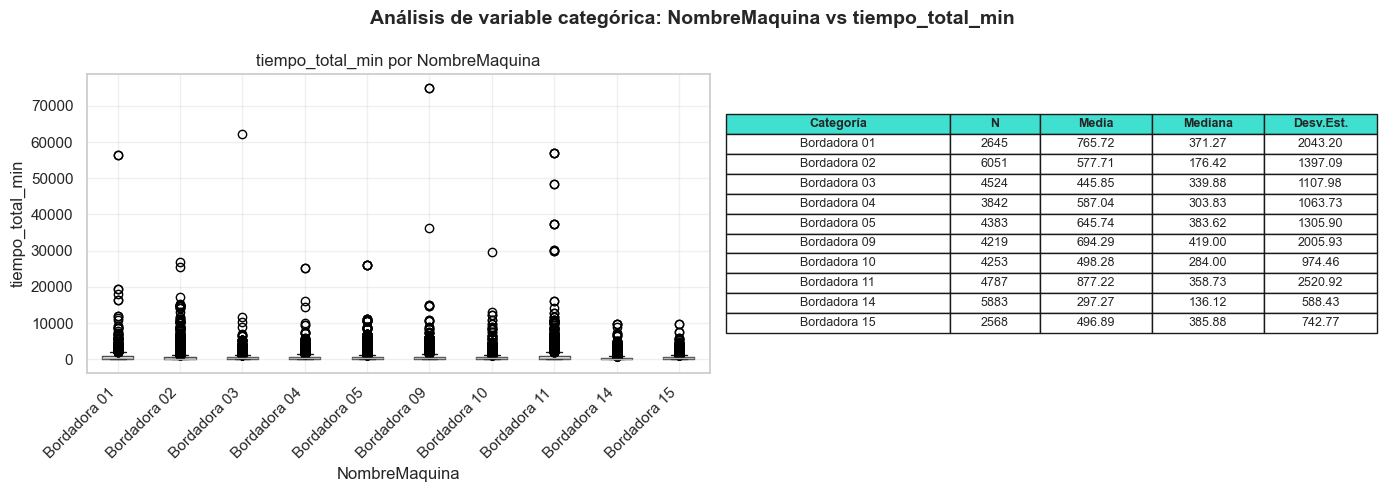


=== Análisis categórico: Operario vs tiempo_total_min ===


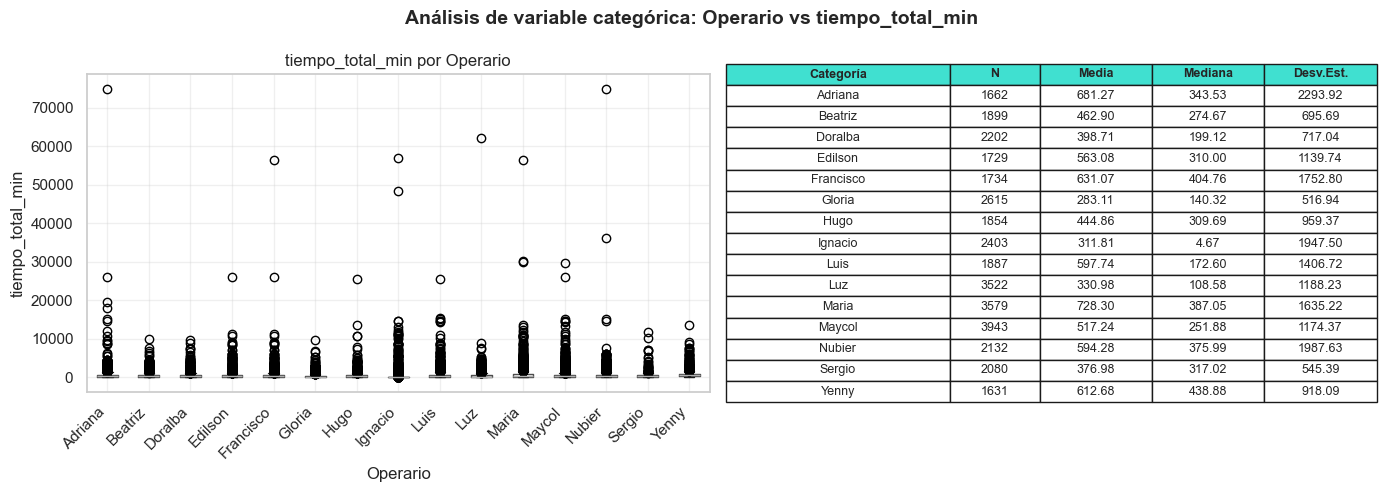


=== Análisis categórico: codigoMaterial vs tiempo_total_min ===


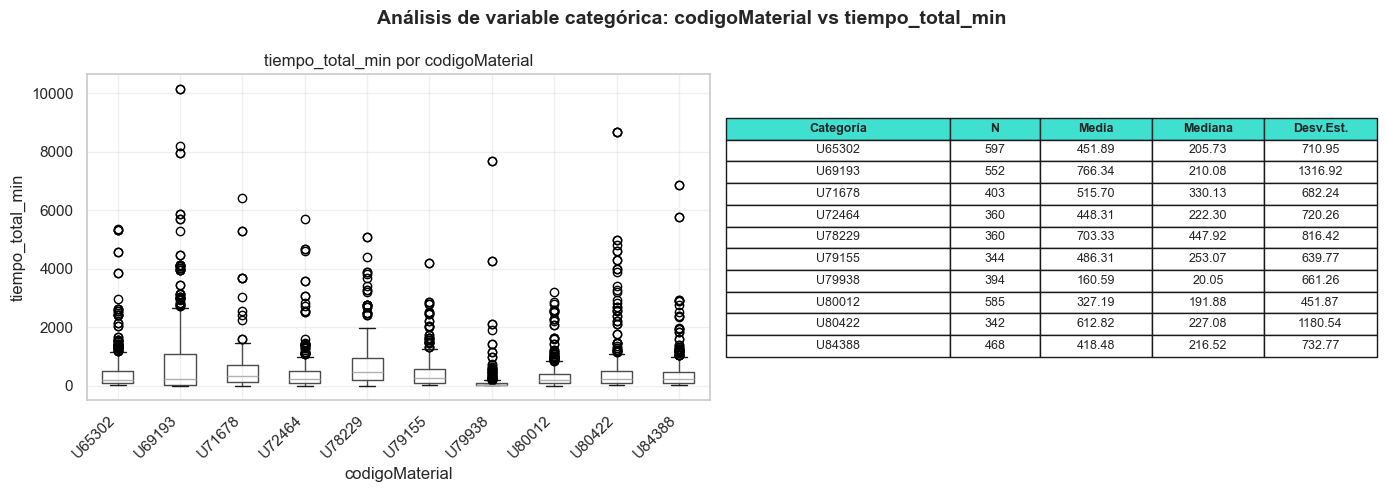


=== Análisis categórico: dia_semana vs tiempo_total_min ===


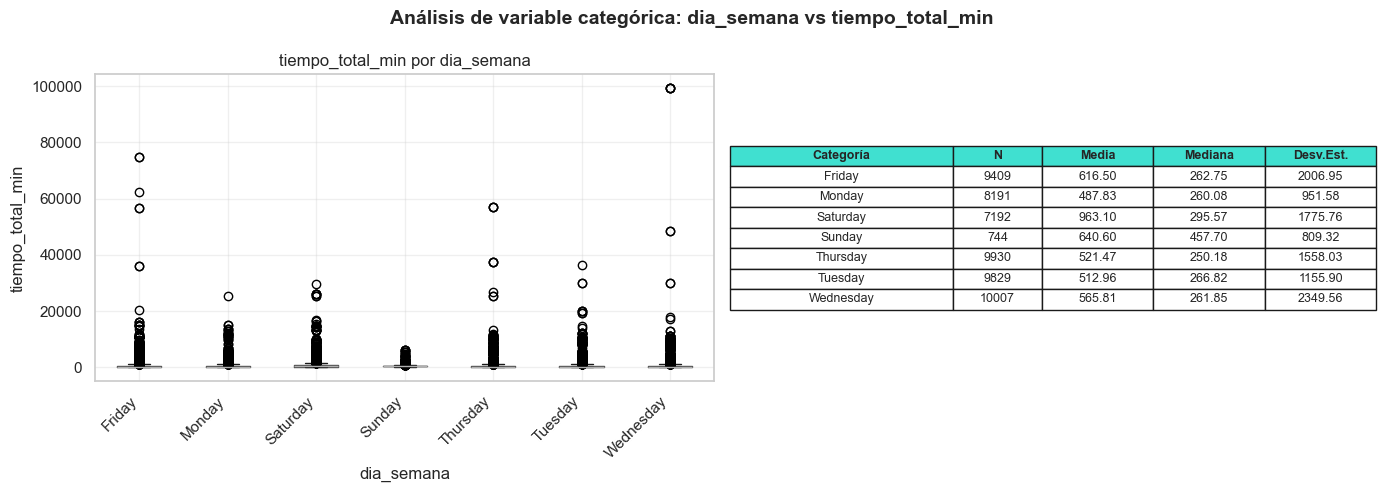


=== Análisis categórico: turno vs tiempo_total_min ===


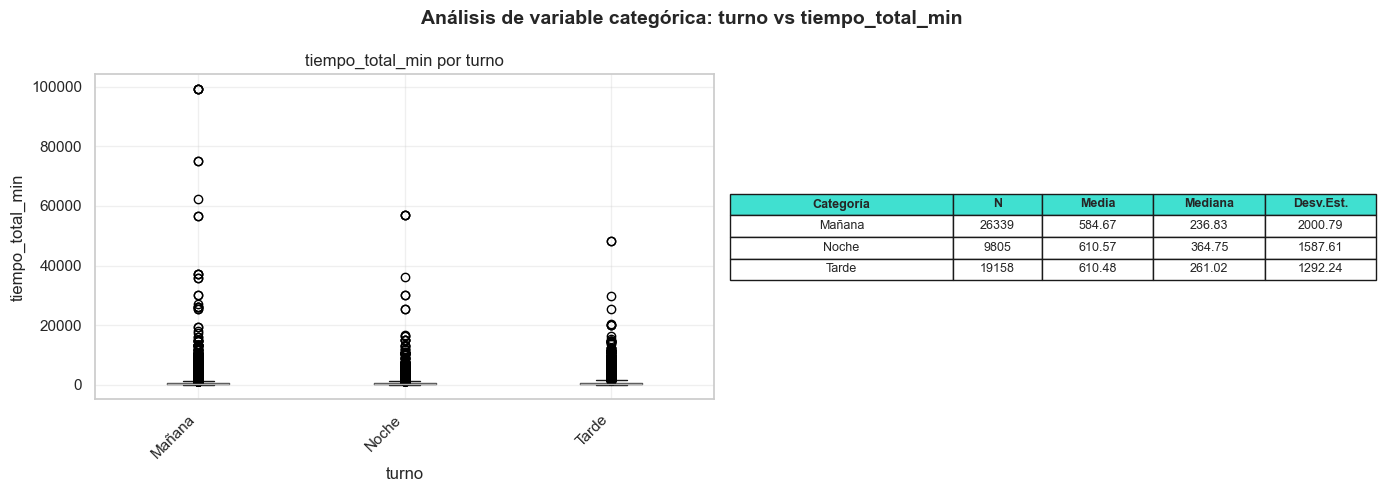

In [54]:
eda_categoricas_produccion_vs_target(df_model, target_col="tiempo_total_min")

### Análisis de estacionalidad

C:\Users\Santiago\AppData\Local\Temp\ipykernel_4572\356751470.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ts, x='mes', y='tiempo_total_min', ax=axes[0], palette='viridis')
C:\Users\Santiago\AppData\Local\Temp\ipykernel_4572\356751470.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Santiago\AppData\Local\Temp\ipykernel_4572\356751470.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ts, x='hora', y='tiempo_total_min', ax=axes[2], palette='coolwarm')


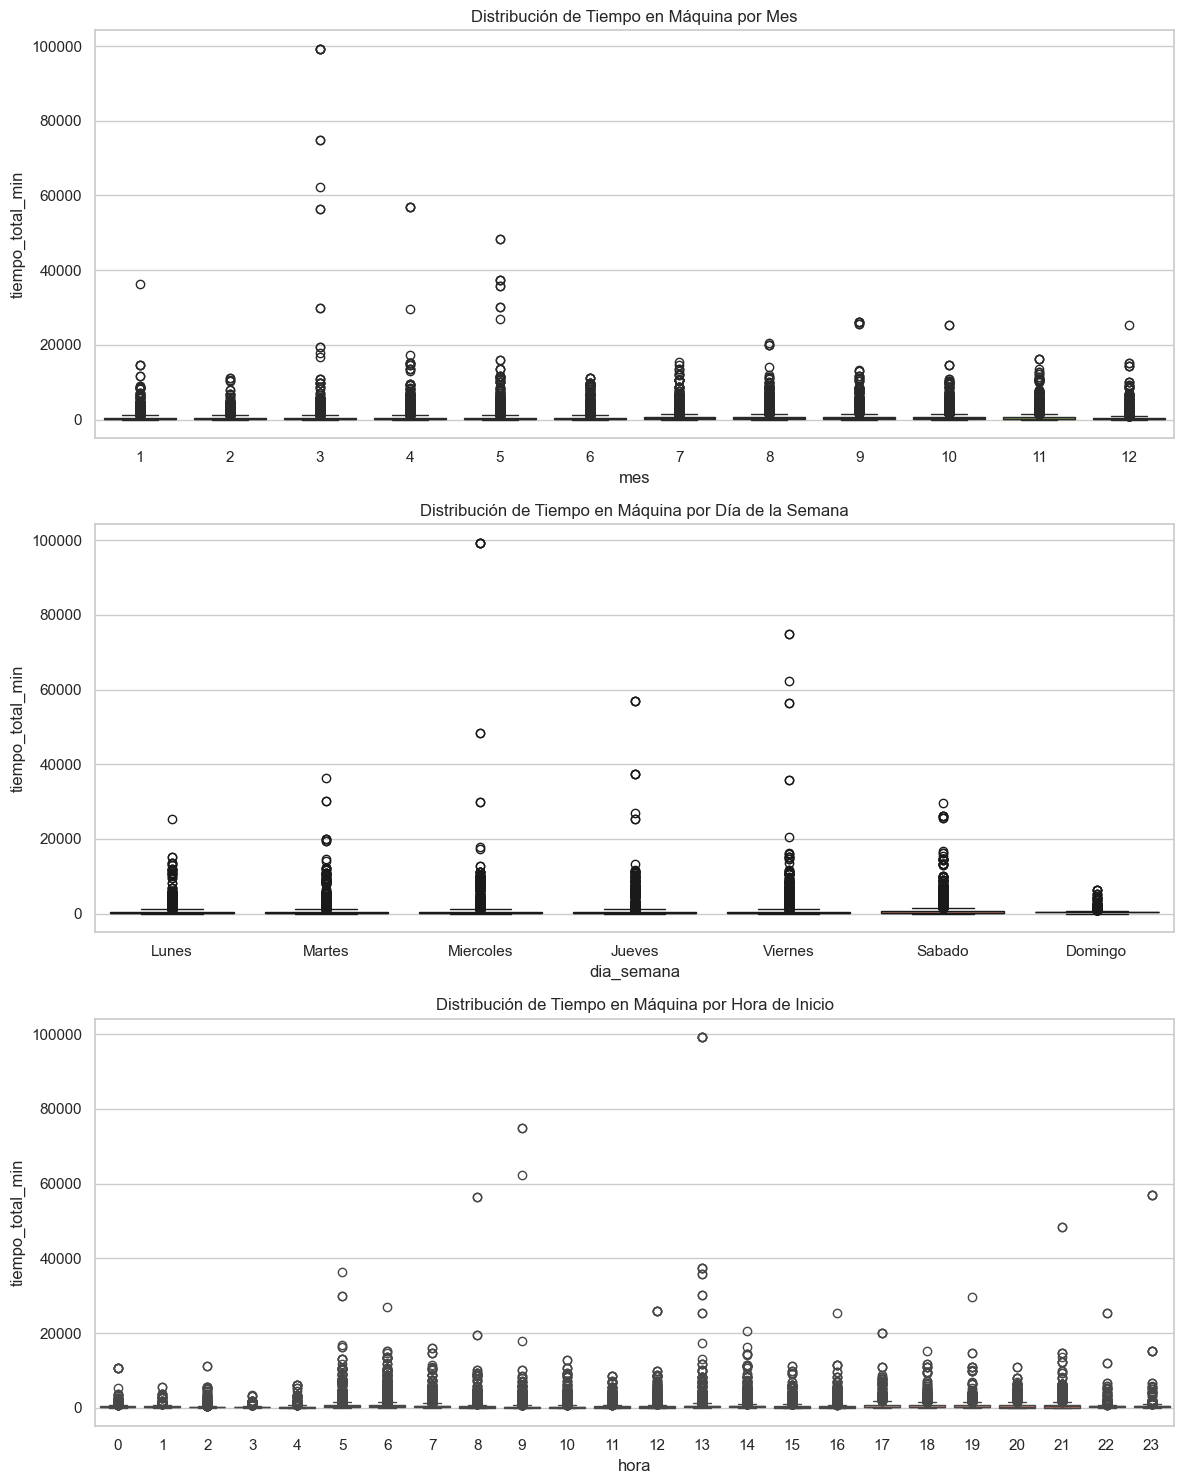

In [55]:
# Crear columnas temporales
if 'FechaInicio' in df_model.columns:
    df_ts = df_model.copy()
    df_ts['FechaInicio'] = pd.to_datetime(df_ts['FechaInicio'], errors='coerce')
    df_ts = df_ts.dropna(subset=['FechaInicio', 'tiempo_total_min'])
    
    df_ts['mes'] = df_ts['FechaInicio'].dt.month
    
    # 1) Día de la semana en inglés
    df_ts['dia_semana'] = df_ts['FechaInicio'].dt.day_name()

    # 2) Mapeo a español
    map_days = {
        'Monday': 'Lunes',
        'Tuesday': 'Martes',
        'Wednesday': 'Miercoles',
        'Thursday': 'Jueves',
        'Friday': 'Viernes',
        'Saturday': 'Sabado',
        'Sunday': 'Domingo',
    }
    df_ts['dia_semana'] = df_ts['dia_semana'].map(map_days)

    df_ts['hora'] = df_ts['FechaInicio'].dt.hour
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 15))
    
    # Por Mes
    sns.boxplot(data=df_ts, x='mes', y='tiempo_total_min', ax=axes[0], palette='viridis')
    axes[0].set_title('Distribución de Tiempo en Máquina por Mes')
    
    # Por Día de la Semana (en español)
    order_days = ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo']
    sns.boxplot(
        data=df_ts,
        x='dia_semana',
        y='tiempo_total_min',
        order=order_days,
        ax=axes[1],
        palette='magma'
    )
    axes[1].set_title('Distribución de Tiempo en Máquina por Día de la Semana')
    
    # Por Hora del Día
    sns.boxplot(data=df_ts, x='hora', y='tiempo_total_min', ax=axes[2], palette='coolwarm')
    axes[2].set_title('Distribución de Tiempo en Máquina por Hora de Inicio')
    
    plt.tight_layout()
    plt.show()
else:
    print("No se encuentra la columna 'FechaInicio' para análisis de estacionalidad.")

### 6. Análisis de Outliers Multivariado

Utilizamos **Isolation Forest** para detectar anomalías que no son evidentes en el análisis univariado (por ejemplo, combinaciones inusuales de tiempo en máquina y cantidad).

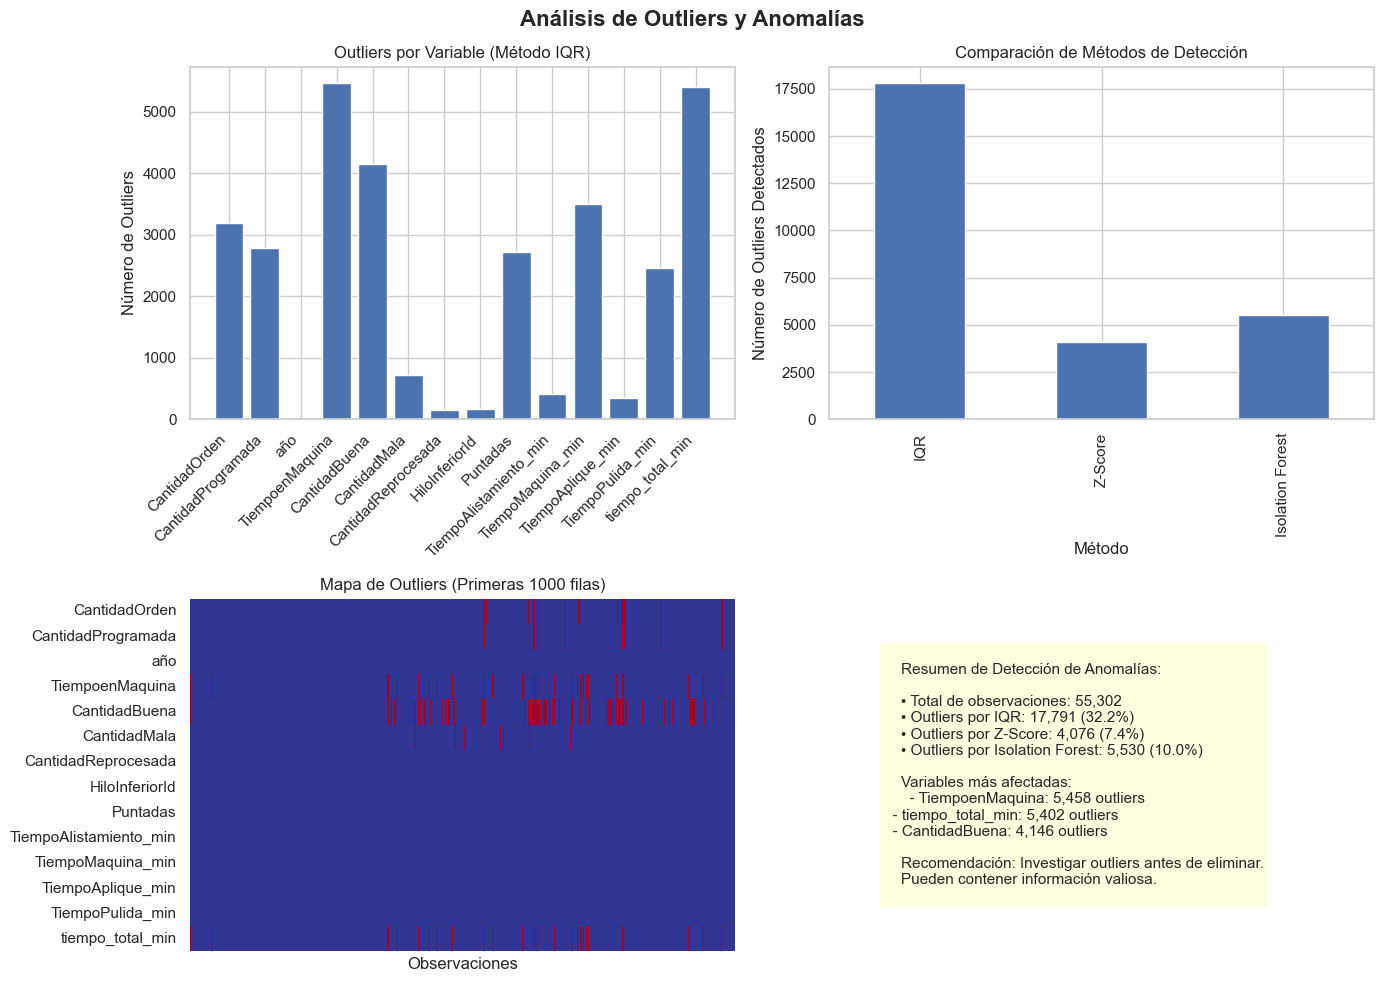

In [56]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

def detect_outliers(df):
    """Detección de outliers usando múltiples métodos"""
    
    numeric_df = df.select_dtypes(include=[np.number])
    
    # Método 1: IQR
    outliers_iqr = pd.DataFrame()
    for col in numeric_df.columns:
        Q1 = numeric_df[col].quantile(0.25)
        Q3 = numeric_df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = ((numeric_df[col] < Q1 - 1.5 * IQR) | 
                   (numeric_df[col] > Q3 + 1.5 * IQR))
        outliers_iqr[col] = outliers
    
    # Método 2: Z-Score
    from scipy import stats
    z_scores = np.abs(stats.zscore(numeric_df.fillna(numeric_df.median())))
    outliers_zscore = (z_scores > 3)
    
    # Método 3: Isolation Forest
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(numeric_df.fillna(numeric_df.median()))
    iso_forest = IsolationForest(contamination=0.1, random_state=42)
    outliers_iso = iso_forest.fit_predict(scaled_data) == -1
    
    # Visualización
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Outliers por columna (IQR)
    ax1 = axes[0, 0]
    outlier_counts = outliers_iqr.sum()
    ax1.bar(range(len(outlier_counts)), outlier_counts.values)
    ax1.set_xticks(range(len(outlier_counts)))
    ax1.set_xticklabels(outlier_counts.index, rotation=45, ha='right')
    ax1.set_title('Outliers por Variable (Método IQR)')
    ax1.set_ylabel('Número de Outliers')
    
    # Plot 2: Distribución de outliers por método
    ax2 = axes[0, 1]
    methods_comparison = pd.DataFrame({
        'IQR': outliers_iqr.any(axis=1).sum(),
        'Z-Score': outliers_zscore.any(axis=1).sum(),
        'Isolation Forest': outliers_iso.sum()
    }, index=['Outliers'])
    methods_comparison.T.plot(kind='bar', ax=ax2, legend=False)
    ax2.set_title('Comparación de Métodos de Detección')
    ax2.set_ylabel('Número de Outliers Detectados')
    ax2.set_xlabel('Método')
    
    # Plot 3: Heatmap de outliers
    ax3 = axes[1, 0]
    sample_outliers = outliers_iqr.head(1000)
    sns.heatmap(sample_outliers.T, cmap='RdYlBu_r', cbar=False, ax=ax3,
               yticklabels=True, xticklabels=False)
    ax3.set_title('Mapa de Outliers (Primeras 1000 filas)')
    ax3.set_xlabel('Observaciones')
    
    # Plot 4: Resumen estadístico
    ax4 = axes[1, 1]
    ax4.axis('off')
    summary_text = f"""
    Resumen de Detección de Anomalías:
    
    • Total de observaciones: {len(df):,}
    • Outliers por IQR: {outliers_iqr.any(axis=1).sum():,} ({outliers_iqr.any(axis=1).sum()/len(df)*100:.1f}%)
    • Outliers por Z-Score: {outliers_zscore.any(axis=1).sum():,} ({outliers_zscore.any(axis=1).sum()/len(df)*100:.1f}%)
    • Outliers por Isolation Forest: {outliers_iso.sum():,} ({outliers_iso.sum()/len(df)*100:.1f}%)
    
    Variables más afectadas:
    {chr(10).join([f'  - {col}: {count:,} outliers' 
                   for col, count in outlier_counts.nlargest(3).items()])}
    
    Recomendación: Investigar outliers antes de eliminar.
    Pueden contener información valiosa.
    """
    ax4.text(0.1, 0.5, summary_text, transform=ax4.transAxes,
            fontsize=11, verticalalignment='center',
            bbox=dict(boxstyle='round', facecolor='lightyellow'))
    
    plt.suptitle('Análisis de Outliers y Anomalías', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return outliers_iqr, outliers_zscore, outliers_iso

outliers_iqr, outliers_zscore, outliers_iso = detect_outliers(df_model)

In [57]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55302 entries, 0 to 55489
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Operario                55302 non-null  category      
 1   MaterialIdOrden         55302 non-null  object        
 2   codigoMaterial          55302 non-null  object        
 3   CantidadOrden           55302 non-null  int64         
 4   NombreMaquina           55302 non-null  category      
 5   CantidadProgramada      55302 non-null  int64         
 6   FechaInicio             55302 non-null  datetime64[ns]
 7   FechaFin                55302 non-null  datetime64[ns]
 8   año                     55302 non-null  int64         
 9   TiempoenMaquina         55302 non-null  float64       
 10  CantidadBuena           55302 non-null  int64         
 11  CantidadMala            55302 non-null  int64         
 12  CantidadReprocesada     55302 non-null  int64      

#### 7.1. Correlación Pearson vs Spearman

Comparamos la correlación lineal (Pearson) con la correlación de rango (Spearman) para detectar relaciones no lineales entre las variables numéricas y el target.

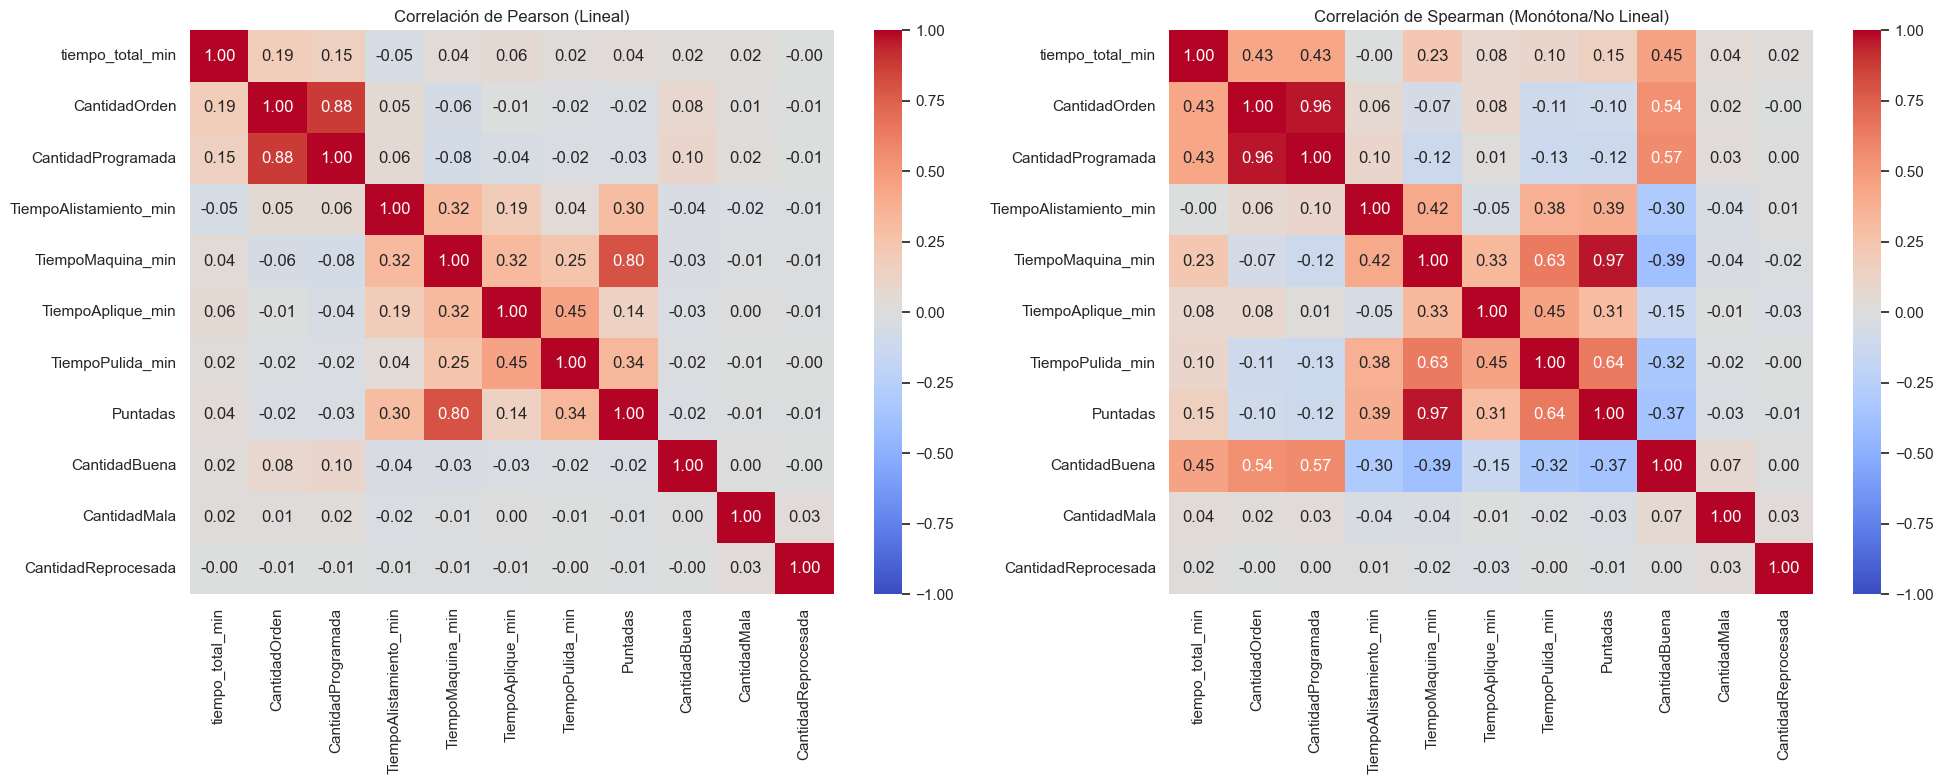

Top Correlaciones Spearman con tiempo_total_min:
tiempo_total_min          1.00
CantidadBuena             0.45
CantidadOrden             0.43
CantidadProgramada        0.43
TiempoMaquina_min         0.23
Puntadas                  0.15
TiempoPulida_min          0.10
TiempoAplique_min         0.08
CantidadMala              0.04
CantidadReprocesada       0.02
TiempoAlistamiento_min   -0.00
Name: tiempo_total_min, dtype: float64


In [58]:
# Seleccionar variables numéricas relevantes
cols_corr = [
    'tiempo_total_min', 'CantidadOrden', 'CantidadProgramada',
    'TiempoAlistamiento_min', 'TiempoMaquina_min', 'TiempoAplique_min', 
    'TiempoPulida_min', 'Velocidad', 'Presion', 'Temperatura',
    'NumeroApliques', 'Puntadas', 'CantidadBuena', 'CantidadMala', 'CantidadReprocesada'
]
# Filtrar las que existen en el df
cols_corr = [c for c in cols_corr if c in df_model.columns]

# Calcular matrices
corr_pearson = df_model[cols_corr].corr(method='pearson')
corr_spearman = df_model[cols_corr].corr(method='spearman')
# Graficar
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0], fmt=".2f")
axes[0].set_title('Correlación de Pearson (Lineal)')

sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1], fmt=".2f")
axes[1].set_title('Correlación de Spearman (Monótona/No Lineal)')

plt.tight_layout()
plt.show()

# Mostrar top correlaciones con el target
if 'tiempo_total_min' in corr_spearman.columns:
    print("Top Correlaciones Spearman con tiempo_total_min:")
    print(corr_spearman['tiempo_total_min'].sort_values(ascending=False))

### Ingenieria de características

In [59]:
import numpy as np
import pandas as pd

def agregar_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # =========================================
    # 0) Imputación de Puntadas + nueva feature
    # =========================================
    if "Puntadas" in df.columns:
        # Imputar Puntadas (si viene vacía)
        df["Puntadas"] = df["Puntadas"].fillna(0)

        # Asegurar CantidadBuena también sin NaN
        if "CantidadBuena" in df.columns:
            df["CantidadBuena"] = df["CantidadBuena"].fillna(0)
        else:
            df["CantidadBuena"] = 0

        # NUEVA FEATURE: puntadas totales por orden
        df["puntadas_totales"] = df["Puntadas"] * df["CantidadBuena"]

    # =========================================
    # 1) Features de FECHA (antes del drop)
    # =========================================
    if "FechaInicio" in df.columns:
        df["FechaInicio_dt"] = pd.to_datetime(df["FechaInicio"], errors="coerce")
        df["dia_semana"] = df["FechaInicio_dt"].dt.dayofweek
        df["mes"] = df["FechaInicio_dt"].dt.month
        df["hora"] = df["FechaInicio_dt"].dt.hour
        df["es_fin_semana"] = df["FechaInicio_dt"].dt.dayofweek.isin([5, 6]).astype(int)

        def clasificar_turno(h):
            if pd.isna(h):
                return "desconocido"
            h = int(h)
            if 6 <= h < 14:
                return "mañana"
            elif 14 <= h < 22:
                return "tarde"
            else:
                return "noche"

        df["turno"] = df["hora"].apply(clasificar_turno)

    return df


In [60]:
# Lista de columnas a eliminar

df_model = agregar_features(df_model)

cols_to_drop = [
    "TiempoAlistamiento",
    "TiempoMaquina",
    "TiempoAplique",
    "TiempoPulida",
    "TiempoAlistamiento_min",
    "TiempoMaquina_min",
    "TiempoAplique_min",
    "TiempoPulida_min",
    "TiempoenMaquina",
    "FechaInicio",
    "FechaFin",
    "MaterialIdOrden",
    "HiloInferiorId",
    "CantidadMala",
    "CantidadReprocesada",
    "CantidadProgramada",
    "CantidadOrden",
    "FechaInicio_dt",
]

# Eliminarlas del dataframe
df_model = df_model.drop(columns=cols_to_drop, errors="ignore")

print("Columnas eliminadas:")
print(cols_to_drop)
print("\nNueva forma del dataset:", df_model.shape)
# Convertir explícitamente a category
df_model['codigoMaterial'] = df_model['codigoMaterial'].astype('category')

df_model

Columnas eliminadas:
['TiempoAlistamiento', 'TiempoMaquina', 'TiempoAplique', 'TiempoPulida', 'TiempoAlistamiento_min', 'TiempoMaquina_min', 'TiempoAplique_min', 'TiempoPulida_min', 'TiempoenMaquina', 'FechaInicio', 'FechaFin', 'MaterialIdOrden', 'HiloInferiorId', 'CantidadMala', 'CantidadReprocesada', 'CantidadProgramada', 'CantidadOrden', 'FechaInicio_dt']

Nueva forma del dataset: (55302, 14)


,Operario,codigoMaterial,NombreMaquina,año,CantidadBuena,PuntoPlantilla,Puntadas,tiempo_total_min,puntadas_totales,dia_semana,mes,hora,es_fin_semana,turno
0,Edward Dario Pulgarin Paniagua,U53554,Bordadora 12,2021,162,1,1735.00,380.00,281070.00,1,6,11,0,mañana
1,Edward Dario Pulgarin Paniagua,U53554,Bordadora 12,2021,471,1,1735.00,6910.00,817185.00,4,6,11,0,mañana
2,Edwin Alonso Jaramillo Castaño,U53554,Bordadora 12,2021,5,1,1735.00,6910.00,8675.00,4,6,11,0,mañana
3,Francisco Nicolas Parra Acevedo,U53554,Bordadora 05,2021,10,1,1735.00,47.00,17350.00,0,3,10,0,mañana
4,Gloria Elsy Jimenez Giraldo,U53554,Bordadora 14,2020,13,1,1735.00,27.00,22555.00,1,7,21,0,tarde
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55485,Doralba Maria Amariles Madrigal,U90747,Bordadora 06,2025,6,0,0.00,33.00,0.00,2,10,15,0,tarde
55486,Ignacio Aristizabal Borja,U90747,Bordadora 06,2025,34,0,0.00,1203.00,0.00,3,10,12,0,mañana
55487,Doralba Maria Amariles Madrigal,U90750,Bordadora 06,2025,20,0,0.00,51.72,0.00,1,10,14,0,tarde
55488,Iliana Del Carmen Gonzalez Duran,U90774,Bordadora 17,2025,17,0,0.00,76.00,0.00,4,10,3,0,noche


In [61]:

from sklearn.model_selection import StratifiedShuffleSplit, train_test_split

def create_train_test_split(df, test_size=0.2, stratify_column='tiempo_total_min'):
    """
    Crea conjuntos de entrenamiento y prueba estratificados para tiempo_total_min.
    """
    # 1. Definir bins dinámicos basados en la distribución real de tus datos
    # Usamos [-inf, Q20, Q40, Q60, Q80, inf] para asegurar 5 grupos equilibrados
    bins = [-np.inf] + df[stratify_column].quantile([0.2, 0.4, 0.6, 0.8]).tolist() + [np.inf]
    
    # Crear columna temporal de categorías
    # Copiamos para evitar warnings
    df_temp = df.copy()
    df_temp['stratify_cat'] = pd.cut(df_temp[stratify_column],
                                     bins=bins,
                                     labels=[1, 2, 3, 4, 5])
    
    # 2. División estratificada
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=42)
    
    for train_idx, test_idx in splitter.split(df_temp, df_temp['stratify_cat']):
        train_set = df_temp.iloc[train_idx].copy()
        test_set = df_temp.iloc[test_idx].copy()
    
    # 3. Verificar proporciones (Tu código de validación)
    print("📊 Verificación de Estratificación:")
    print("=" * 50)
    original_props = df_temp['stratify_cat'].value_counts(normalize=True).sort_index()
    train_props = train_set['stratify_cat'].value_counts(normalize=True).sort_index()
    test_props = test_set['stratify_cat'].value_counts(normalize=True).sort_index()
    
    comparison = pd.DataFrame({
        'Original': original_props,
        'Train': train_props,
        'Test': test_props
    })
    # Calculamos el error relativo
    comparison['Train_Error_%'] = (comparison['Train'] / comparison['Original'] - 1) * 100
    comparison['Test_Error_%'] = (comparison['Test'] / comparison['Original'] - 1) * 100
    
    # Mostramos tabla redondeada
    print(comparison.round(4)) # 4 decimales para ver mejor la precisión
    
    # 4. Limpieza final: eliminar la columna auxiliar 'stratify_cat'
    for set_ in (train_set, test_set):
        set_.drop('stratify_cat', axis=1, inplace=True)

    print(f"\nConjuntos creados exitosamente:")
    print(f"   • Entrenamiento: {len(train_set):,} filas")
    print(f"   • Prueba: {len(test_set):,} filas")
    
    return train_set, test_set

# --- Ejecución con tu df_model ---
# Asegúrate de haber hecho la limpieza previa (el drop del '11CM')
strat_train_set, strat_test_set = create_train_test_split(df_model, test_size=0.2, stratify_column='tiempo_total_min')

📊 Verificación de Estratificación:
              Original  Train  Test  Train_Error_%  Test_Error_%
stratify_cat                                                    
1                 0.20   0.20  0.20          -0.00          0.01
2                 0.20   0.20  0.20          -0.00          0.01
3                 0.20   0.20  0.20           0.00         -0.01
4                 0.20   0.20  0.20           0.00         -0.01
5                 0.20   0.20  0.20           0.00         -0.01

Conjuntos creados exitosamente:
   • Entrenamiento: 44,241 filas
   • Prueba: 11,061 filas


In [62]:
import pandas as pd
import numpy as np
import re

def aplicar_codificacion(train_df, test_df, target_col="tiempo_total_min", alpha=5):
    """
    Aplica:
      1) Target encoding con smoothing a varias columnas categóricas
         (Operario, NombreMaquina, codigoMaterial).
      2) One-hot encoding a turno (Mañana/Tarde/Noche).
      3) One-hot encoding a PuntoPlantilla.
      4) Imputación de Puntadas.
      5) Separación X / y.
    """

    # Copias por seguridad
    train_df = train_df.copy()
    test_df = test_df.copy()

    # ============================================================
    # 1) Columnas a codificar por TARGET ENCODING (SIN turno)
    # ============================================================
    te_cols = [
        "Operario",
        "NombreMaquina",
        "codigoMaterial",
    ]

    # Asegurar string en columnas TE
    for col in te_cols:
        if col in train_df.columns:
            train_df[col] = train_df[col].astype(str)
        if col in test_df.columns:
            test_df[col] = test_df[col].astype(str)

    # ============================================================
    # 2) TARGET ENCODING CON SMOOTHING
    # ============================================================
    y_train = train_df[target_col].copy()
    y_test = test_df[target_col].copy()

    global_mean = y_train.mean()
    enc_maps = {}

    for col in te_cols:
        if col not in train_df.columns:
            continue

        stats = train_df.groupby(col)[target_col].agg(["mean", "count"])
        stats["enc"] = (stats["mean"] * stats["count"] + global_mean * alpha) / (stats["count"] + alpha)

        enc_maps[col] = stats["enc"]

        # Aplicar a train y test
        train_df[f"{col}_encoded"] = train_df[col].map(enc_maps[col]).fillna(global_mean)
        if col in test_df.columns:
            test_df[f"{col}_encoded"] = test_df[col].map(enc_maps[col]).fillna(global_mean)
        else:
            test_df[f"{col}_encoded"] = global_mean

    # 🔹 Ahora SÍ borramos las columnas originales que ya tienen versión _encoded
    train_df = train_df.drop(columns=te_cols, errors="ignore")
    test_df = test_df.drop(columns=te_cols, errors="ignore")

    # ============================================================
    # 3) ONE-HOT ENCODING DE TURNO (NO target encoding)
    # ============================================================
    if "turno" in train_df.columns:
        train_df["turno"] = train_df["turno"].astype(str).str.strip()
    if "turno" in test_df.columns:
        test_df["turno"] = test_df["turno"].astype(str).str.strip()

    if "turno" in train_df.columns:
        train_df = pd.get_dummies(train_df, columns=["turno"], prefix="turno", drop_first=True)
    if "turno" in test_df.columns:
        test_df = pd.get_dummies(test_df, columns=["turno"], prefix="turno", drop_first=True)

    # Alinear columnas de turno y forzar 0/1 int
    turno_cols = sorted(
        set(
            [c for c in train_df.columns if c.startswith("turno_")] +
            [c for c in test_df.columns if c.startswith("turno_")]
        )
    )
    for df_ in (train_df, test_df):
        for c in turno_cols:
            if c not in df_.columns:
                df_[c] = 0
            df_[c] = df_[c].astype(int)

    # ============================================================
    # 4) ONE-HOT ENCODING DE PUNTO PLANTILLA
    # ============================================================
    drop_value = 'dejar arriba hacia abajo 11cm'

    if "PuntoPlantilla" in train_df.columns:
        train_df['PuntoPlantilla'] = train_df['PuntoPlantilla'].astype(str).str.strip()
    if "PuntoPlantilla" in test_df.columns:
        test_df['PuntoPlantilla'] = test_df['PuntoPlantilla'].astype(str).str.strip()

    # Construir máscaras de filas que SE QUEDAN
    if "PuntoPlantilla" in train_df.columns:
        mask_train = train_df['PuntoPlantilla'].str.lower() != drop_value
    else:
        mask_train = pd.Series(True, index=train_df.index)

    if "PuntoPlantilla" in test_df.columns:
        mask_test = test_df['PuntoPlantilla'].str.lower() != drop_value
    else:
        mask_test = pd.Series(True, index=test_df.index)

    # Aplicar el MISMO filtro a df y al target
    train_df = train_df.loc[mask_train].copy()
    test_df = test_df.loc[mask_test].copy()
    y_train = y_train.loc[mask_train].copy()
    y_test = y_test.loc[mask_test].copy()

    # One-hot PuntoPlantilla
    if "PuntoPlantilla" in train_df.columns:
        train_df = pd.get_dummies(train_df, columns=['PuntoPlantilla'], prefix='Plantilla', drop_first=True)
    if "PuntoPlantilla" in test_df.columns:
        test_df = pd.get_dummies(test_df, columns=['PuntoPlantilla'], prefix='Plantilla', drop_first=True)

    # Forzar columnas Plantilla_* a 0/1 int
    for df_ in (train_df, test_df):
        plant_cols = [c for c in df_.columns if c.startswith("Plantilla_")]
        for c in plant_cols:
            df_[c] = df_[c].astype(int)

    # ============================================================
    # 5) IMPUTACIÓN PUNTADAS
    # ============================================================
    if "Puntadas" in train_df.columns:
        train_df["Puntadas"] = train_df["Puntadas"].fillna(0)
    if "Puntadas" in test_df.columns:
        test_df["Puntadas"] = test_df["Puntadas"].fillna(0)

    # ============================================================
    # 5.1) Convertir cualquier bool restante a int (0/1)
    # ============================================================
    for df_ in (train_df, test_df):
        bool_cols = df_.select_dtypes(include=["bool"]).columns
        if len(bool_cols) > 0:
            df_[bool_cols] = df_[bool_cols].astype(int)

    # ============================================================
    # 6) ORDENAR COLUMNAS ESTRUCTURADAMENTE
    # ============================================================
    train_df = train_df.reindex(sorted(train_df.columns), axis=1)
    test_df = test_df.reindex(sorted(test_df.columns), axis=1)

    # ============================================================
    # 7) SEPARAR X E Y
    # ============================================================
    X_train = train_df.drop(columns=[target_col])
    X_test = test_df.drop(columns=[target_col])

    return X_train, y_train, X_test, y_test, enc_maps

In [63]:
X_train, y_train, X_test, y_test, enc_maps = aplicar_codificacion(
    strat_train_set,
    strat_test_set,
    target_col="tiempo_total_min",
    alpha=5
)

In [64]:
# ✅ Ya no tiene tiempo_total_min (se separó en celda 53)
prod_labels = y_train.copy()
prod_prepared = X_train.copy()

prod_num = prod_prepared.select_dtypes(include=[np.number])
prod_cat = prod_prepared.select_dtypes(include=['object'])

print(f"📊 Preparación de datos:")
print(f"   • Características numéricas: {prod_num.shape[1]}")
print(f"   • Características categóricas: {prod_cat.shape[1]}")
print(f"   • Total de características: {prod_prepared.shape[1]}")
print(f"   • Muestras de entrenamiento: {len(prod_prepared):,}")

prod_prepared

📊 Preparación de datos:
   • Características numéricas: 14
   • Características categóricas: 0
   • Total de características: 14
   • Muestras de entrenamiento: 44,233


,CantidadBuena,NombreMaquina_encoded,Operario_encoded,Plantilla_1,Puntadas,año,codigoMaterial_encoded,dia_semana,es_fin_semana,hora,mes,puntadas_totales,turno_noche,turno_tarde
40830,66,300.90,277.95,0,0.00,2024,284.24,3,0,4,8,0.00,1,0
19645,90,564.97,361.59,0,442.00,2024,320.88,3,0,19,7,39780.00,0,1
10787,240,448.56,384.66,0,2003.00,2021,582.26,2,0,6,2,480720.00,0,0
20164,416,652.92,603.34,1,860.00,2022,277.13,0,0,15,1,357760.00,0,1
55024,34,843.38,418.02,0,0.00,2025,1390.19,0,0,20,10,0.00,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7557,192,579.33,463.19,0,1848.00,2020,414.73,1,0,5,9,354816.00,1,0
36584,58,559.96,1005.75,0,0.00,2023,445.80,0,0,18,11,0.00,0,1
51250,58,579.33,618.09,0,0.00,2025,1080.08,4,0,13,8,0.00,0,0
54653,16,506.22,472.37,0,0.00,2025,453.43,2,0,19,7,0.00,0,1


Columnas usadas en la correlación:
['CantidadBuena', 'NombreMaquina_encoded', 'Operario_encoded', 'Plantilla_1', 'Puntadas', 'año', 'codigoMaterial_encoded', 'dia_semana', 'es_fin_semana', 'hora', 'mes', 'puntadas_totales', 'turno_noche', 'turno_tarde', 'tiempo_total_min']


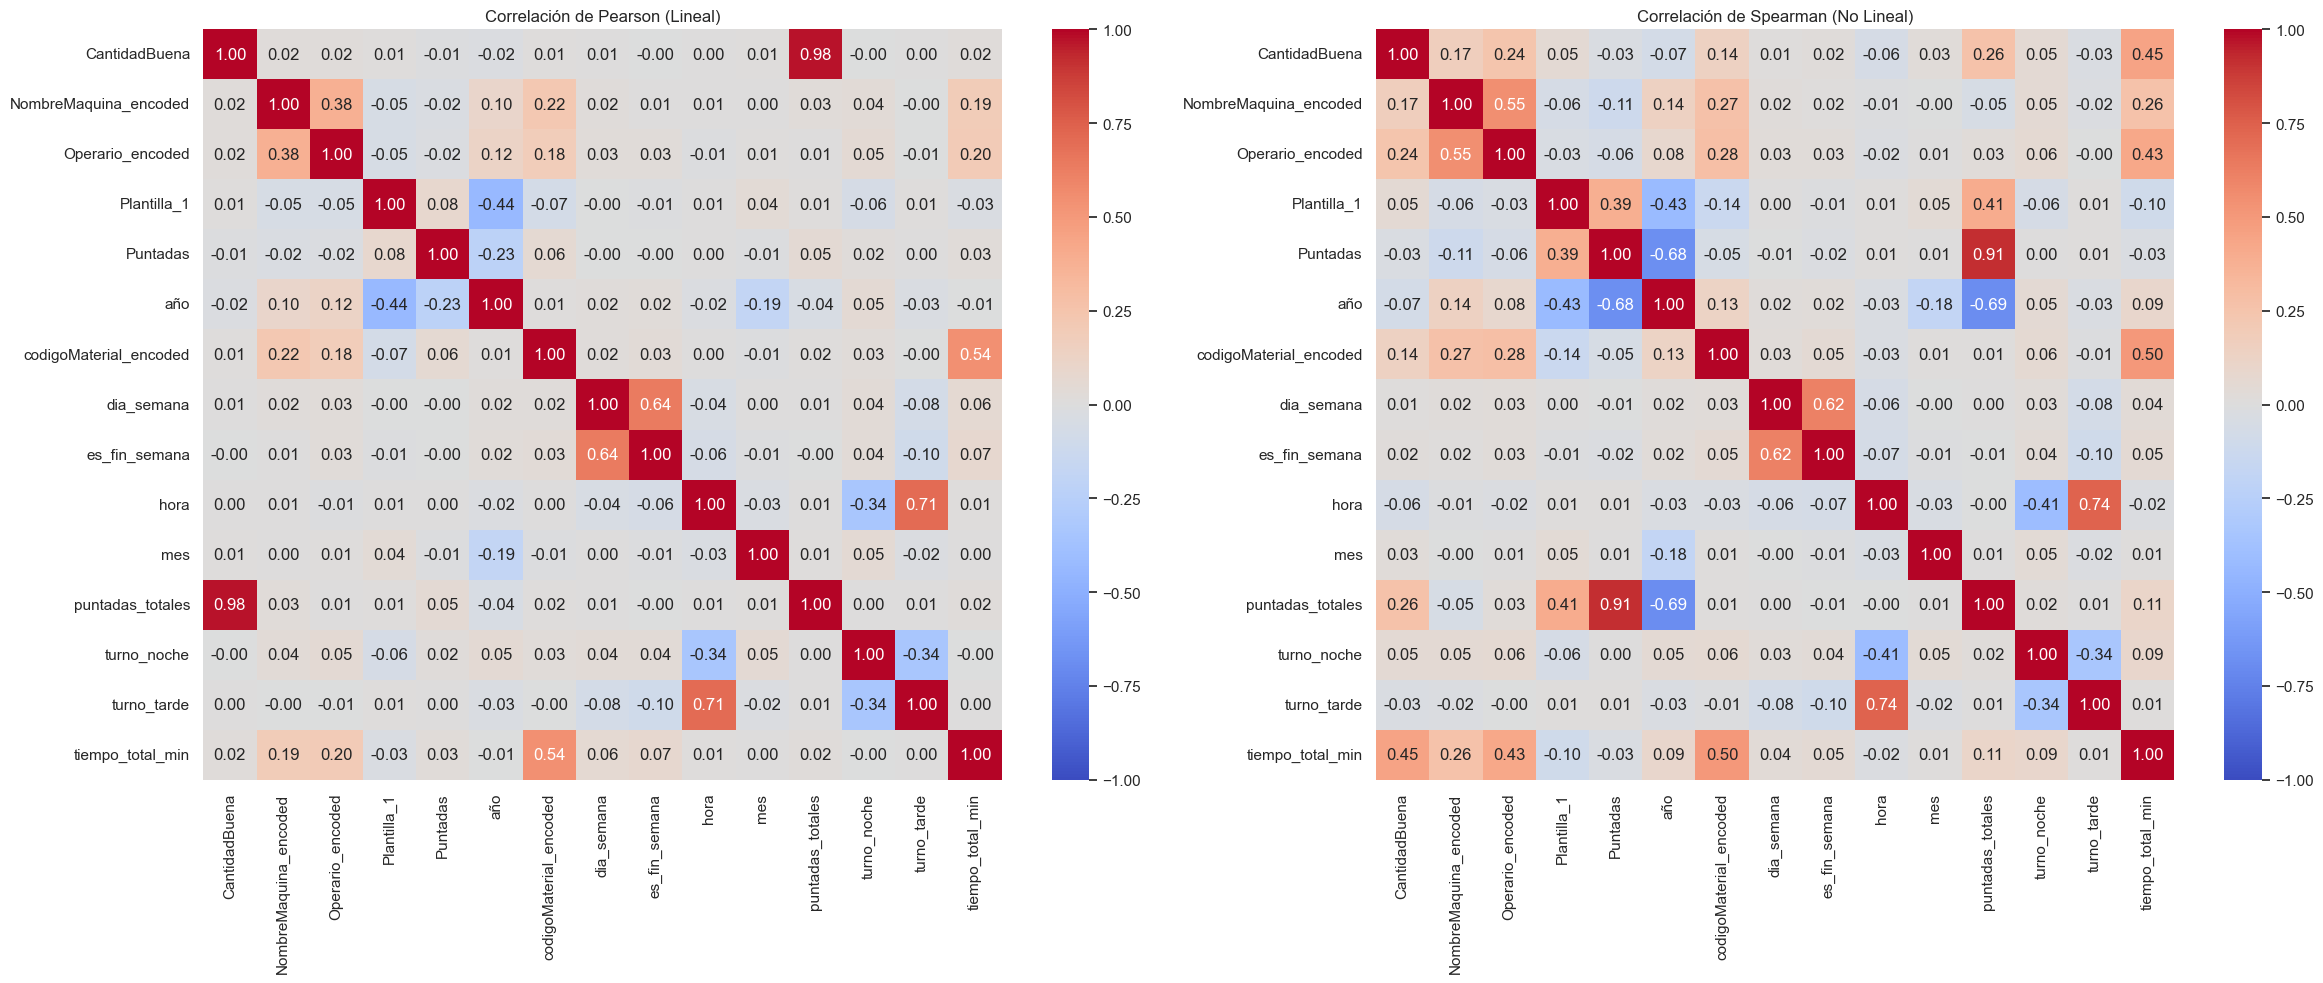

In [65]:
# ✅ 1. Reconstruir un DataFrame con features + target
df_corr = prod_prepared.copy()              # X_train ya codificado
df_corr["tiempo_total_min"] = prod_labels.values  # y_train

# ✅ 2. Usar TODAS las columnas numéricas + bool (incluye encoded, dummies, etc.)
num_cols = df_corr.select_dtypes(include=[np.number, "bool"]).columns.tolist()
print("Columnas usadas en la correlación:")
print(num_cols)

# Convertir bool → float para que todo sea homogéneo
df_corr[num_cols] = df_corr[num_cols].astype(float)

# ✅ 3. Calcular matrices de correlación
corr_pearson = df_corr[num_cols].corr(method='pearson')
corr_spearman = df_corr[num_cols].corr(method='spearman')

# ✅ 4. Graficar heatmaps con anotaciones
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

sns.heatmap(
    corr_pearson,
    annot=True,        # 👈 ahora sí muestra el valor
    fmt=".2f",         # 2 decimales
    cmap='coolwarm',
    vmin=-1, vmax=1,
    ax=axes[0]
)
axes[0].set_title('Correlación de Pearson (Lineal)')

sns.heatmap(
    corr_spearman,
    annot=True,        # 👈 también aquí
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1, vmax=1,
    ax=axes[1]
)
axes[1].set_title('Correlación de Spearman (No Lineal)')

plt.tight_layout()
plt.show()


In [ ]:
# Instalar paquetes necesarios (si no están instalados)
import subprocess
import sys
# Importar modelos
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Definir modelos a evaluar
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Elastic Net': ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0),
    'LightGBM': LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
    'CatBoost': CatBoostRegressor(iterations=100, verbose=0, random_state=42),

}

print("\n Modelos importados y definidos:")
print(f"   • Total de modelos: {len(models)}")
print(f"   • Modelos: {list(models.keys())}")
print(f"\n Dimensiones de datos:")
print(f"   X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"   y_train: {y_train.shape} | y_test: {y_test.shape}")


✅ Modelos importados y definidos:
   • Total de modelos: 10
   • Modelos: ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'Elastic Net', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'XGBoost', 'LightGBM', 'CatBoost']

📊 Dimensiones de datos:
   X_train: (44233, 14) | X_test: (11059, 14)
   y_train: (44233,) | y_test: (11059,)


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import time

# =============================================================================
# 1. CONFIGURACIÓN DE LOS ESPACIOS DE BÚSQUEDA (CORREGIDOS)
# =============================================================================

# A. Random Forest: Permitimos más profundidad y hojas más pequeñas
rf_params = {
    'n_estimators': [200, 300],
    'max_depth': [15, 25, 30, None],       # None permite crecer si es necesario
    'min_samples_split': [5, 10, 20],      # Bajamos de 50 a 5-20
    'min_samples_leaf': [2, 5, 10],        # Bajamos de 30 a 2-10 (Clave para R2)
    'max_features': ['sqrt', 0.5],         # Buena regularización
    'max_samples': [0.7, 0.9]              # Bootstrap subsampling
}

# B. Extra Trees: Suele necesitar menos regularización que RF
et_params = {
    'n_estimators': [200, 300],
    'max_depth': [15, 25, None],
    'min_samples_leaf': [2, 5, 10],
    'max_features': [0.7, 0.9, 1.0],       # ExtraTrees funciona bien con muchas features
    'bootstrap': [True, False]             # Probar con y sin bootstrap
}

# C. Gradient Boosting: El más potente, requiere learning rate bajo
gb_params = {
    'n_estimators': [200, 400, 600],
    'learning_rate': [0.01, 0.05, 0.1],    # CLAVE: LR bajo + muchos árboles
    'max_depth': [3, 5, 7],                # Boosting prefiere árboles poco profundos
    'min_samples_leaf': [10, 20],
    'subsample': [0.7, 0.8, 0.9],          # Evita overfitting aleatorizando filas
    'max_features': ['sqrt', 0.8]
}

# Lista de modelos a optimizar
models_to_tune = [
    ('Random Forest', RandomForestRegressor(random_state=42, n_jobs=-1), rf_params),
    ('Extra Trees', ExtraTreesRegressor(random_state=42, n_jobs=-1), et_params),
    ('Gradient Boosting', GradientBoostingRegressor(random_state=42), gb_params)
]

# =============================================================================
# 2. EJECUCIÓN DEL BUCLE DE OPTIMIZACIÓN
# =============================================================================

results_tuning = []

print(f" Iniciando optimización de {len(models_to_tune)} modelos...")
print(f"   Filas de entrenamiento: {len(X_train)}")

for name, model, params in models_to_tune:
    print(f"\n Optimizando: {name}...")
    start = time.time()
    
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=20,              # 20 combinaciones inteligentes por modelo
        cv=3,                   # 3 folds es suficiente y rápido
        scoring='r2',           # Maximizamos R2
        n_jobs=-1,
        random_state=42,
        verbose=1
    )
    
    # Entrenar
    search.fit(X_train, y_train) # Asumiendo que y_train ya tiene Log si lo decidiste, o es normal
    
    # Obtener el mejor
    best_model = search.best_estimator_
    
    # Evaluar
    y_pred = best_model.predict(X_test)
    
    # Métricas
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    # Guardar
    results_tuning.append({
        'Modelo': name,
        'R² Test': r2,
        'RMSE': rmse,
        'MAE': mae,
        'Mejores Params': search.best_params_
    })
    
    print(f"   Terminado en {(time.time() - start)/60:.1f} min. | R²: {r2:.4f}")

# =============================================================================
# 3. RESULTADOS FINALES
# =============================================================================
print("\n TABLA FINAL DE MEJORES MODELOS OPTIMIZADOS")
df_results = pd.DataFrame(results_tuning).sort_values('R² Test', ascending=False)
print(df_results[['Modelo', 'R² Test', 'RMSE', 'MAE']].to_markdown(index=False, floatfmt=".4f"))

print("\n Mejores Hiperparámetros del Ganador:")
best_params = df_results.iloc[0]['Mejores Params']
for k, v in best_params.items():
    print(f" • {k}: {v}")

🚀 Iniciando optimización de 3 modelos...
   Filas de entrenamiento: 44233

⚡ Optimizando: Random Forest...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
   Terminado en 1.7 min. | R²: 0.0613

⚡ Optimizando: Extra Trees...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
   Terminado en 1.5 min. | R²: 0.1858

⚡ Optimizando: Gradient Boosting...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
   Terminado en 0.9 min. | R²: 0.2218

🏆 TABLA FINAL DE MEJORES MODELOS OPTIMIZADOS
| Modelo            |   R² Test |      RMSE |      MAE |
|:------------------|----------:|----------:|---------:|
| Gradient Boosting |    0.2218 | 1038.1960 | 415.2372 |
| Extra Trees       |    0.1858 | 1061.9717 | 381.7965 |
| Random Forest     |    0.0613 | 1140.2921 | 404.5653 |

💡 Mejores Hiperparámetros del Ganador:
 • subsample: 0.7
 • n_estimators: 600
 • min_samples_leaf: 10
 • max_features: sqrt
 • max_depth: 7
 • learning_rate: 0.05


In [ ]:

# Función para evaluar modelos
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """
    Evalúa un modelo en train y test, calcula métricas.
    """
    # Predicciones
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Métricas en train
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    mae_train = mean_absolute_error(y_train, y_pred_train)
    r2_train = r2_score(y_train, y_pred_train)
    
    # Métricas en test
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mae_test = mean_absolute_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)
    
    # MAPE (Mean Absolute Percentage Error)
    mape_test = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100
    
    results = {
        'Modelo': model_name,
        'RMSE_train': rmse_train,
        'RMSE_test': rmse_test,
        'MAE_train': mae_train,
        'MAE_test': mae_test,
        'R²_train': r2_train,
        'R²_test': r2_test,
        'MAPE_%': mape_test,
        'Overfitting': r2_train - r2_test  # Diferencia positiva = overfitting
    }
    
    return results, y_pred_test

print("✅ Función evaluate_model definida correctamente")

✅ Función evaluate_model definida correctamente


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44233 entries, 40830 to 13214
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CantidadBuena           44233 non-null  int64  
 1   NombreMaquina_encoded   44233 non-null  float64
 2   Operario_encoded        44233 non-null  float64
 3   Plantilla_1             44233 non-null  int32  
 4   Puntadas                44233 non-null  float64
 5   año                     44233 non-null  int64  
 6   codigoMaterial_encoded  44233 non-null  float64
 7   dia_semana              44233 non-null  int32  
 8   es_fin_semana           44233 non-null  int32  
 9   hora                    44233 non-null  int32  
 10  mes                     44233 non-null  int32  
 11  puntadas_totales        44233 non-null  float64
 12  turno_noche             44233 non-null  int32  
 13  turno_tarde             44233 non-null  int32  
dtypes: float64(5), int32(7), int64(2)
memor

In [ ]:
# Entrenar y evaluar cada modelo
results_list = []

print(" Entrenando modelos...")
print("=" * 70)

for name, model in models.items():
    print(f"  {name:25s}", end="", flush=True)
    
    try:
        # Entrenar modelo
        model.fit(X_train, y_train)
        
        # Evaluar modelo
        results, predictions = evaluate_model(model, X_train, y_train, X_test, y_test, name)
        results_list.append(results)
        
        print(f" R² Test: {results['R²_test']:7.4f} | RMSE: {results['RMSE_test']:8.2f}")
    
    except Exception as e:
        print(f" Error: {str(e)[:40]}")
        continue

# Crear DataFrame con resultados
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values('R²_test', ascending=False)

print("\n" + "=" * 70)
print("📊 COMPARACIÓN DE MODELOS (Ordenados por R² en Test)")
print("=" * 70)

# Mostrar tabla con colores
display(results_df[['Modelo', 'R²_train', 'R²_test', 'RMSE_test', 'MAE_test', 'MAPE_%', 'Overfitting']].style
    .format({
        'R²_train': '{:.4f}',
        'R²_test': '{:.4f}',
        'RMSE_test': '{:.2f}',
        'MAE_test': '{:.2f}',
        'MAPE_%': '{:.2f}',
        'Overfitting': '{:.4f}'
    })
    .background_gradient(subset=['R²_test'], cmap='RdYlGn', vmin=0, vmax=1)
    .background_gradient(subset=['RMSE_test', 'MAE_test'], cmap='RdYlGn_r')
)

# Resumen
print(f"\nMEJOR MODELO: {results_df.iloc[0]['Modelo']}")
print(f"   R² Test: {results_df.iloc[0]['R²_test']:.4f}")
print(f"   RMSE: {results_df.iloc[0]['RMSE_test']:.2f}")
print(f"   MAE: {results_df.iloc[0]['MAE_test']:.2f}")
print(f"   MAPE: {results_df.iloc[0]['MAPE_%']:.2f}%")


top2_model_names = results_df.head(2)['Modelo'].tolist()

 Entrenando modelos...
  Linear Regression         R² Test: -0.0473 | RMSE:  1204.42
  Ridge Regression          R² Test: -0.0473 | RMSE:  1204.42
  Lasso Regression          R² Test: -0.0473 | RMSE:  1204.41
  Elastic Net               R² Test: -0.0479 | RMSE:  1204.75
  Random Forest             R² Test:  0.1031 | RMSE:  1114.58
  Extra Trees               R² Test:  0.4367 | RMSE:   883.34
  Gradient Boosting         R² Test:  0.1581 | RMSE:  1079.87
  XGBoost                   R² Test:  0.1440 | RMSE:  1088.86
  LightGBM                  R² Test:  0.2121 | RMSE:  1044.69
  CatBoost                  R² Test:  0.1771 | RMSE:  1067.60

📊 COMPARACIÓN DE MODELOS (Ordenados por R² en Test)


,Modelo,R²_train,R²_test,RMSE_test,MAE_test,MAPE_%,Overfitting
5,Extra Trees,1.0000,0.4367,883.34,368.79,inf,0.5633
8,LightGBM,0.7194,0.2121,1044.69,421.19,inf,0.5073
9,CatBoost,0.8350,0.1771,1067.60,424.99,inf,0.6578
6,Gradient Boosting,0.6938,0.1581,1079.87,454.78,inf,0.5357
7,XGBoost,0.8227,0.1440,1088.86,413.47,inf,0.6786
4,Random Forest,0.9353,0.1031,1114.58,404.51,inf,0.8322
2,Lasso Regression,0.3109,-0.0473,1204.41,544.66,inf,0.3582
0,Linear Regression,0.3109,-0.0473,1204.42,544.71,inf,0.3582
1,Ridge Regression,0.3109,-0.0473,1204.42,544.71,inf,0.3582
3,Elastic Net,0.3107,-0.0479,1204.75,543.18,inf,0.3586



MEJOR MODELO: Extra Trees
   R² Test: 0.4367
   RMSE: 883.34
   MAE: 368.79
   MAPE: inf%


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import make_scorer, r2_score
import time
import pandas as pd

# Definir scorer
r2_scorer = make_scorer(r2_score)


print(" EXTRA TREES")
print("="*80)

# Modelo Base (El que te dio 0.43)
et_base = ExtraTreesRegressor(random_state=42, n_jobs=-1)

# Grilla "Permisiva" (Dejamos que sea profundo, solo ajustamos detalles)
param_dist_et = {
    'n_estimators': [100, 200, 300, 500],    # Más árboles suelen estabilizar la predicción
    'max_depth': [None, 20, 30, 40],         # 'None' es clave: permite profundidad infinita (lo que funcionó)
    'min_samples_split': [2, 5, 10],         # Bajos para capturar detalles
    'min_samples_leaf': [1, 2, 4],           # Muy bajos. Si subimos esto, matamos el R2.
    'max_features': ['sqrt', 'log2', None, 0.8], # 'None' usa todas las cols (máxima potencia)
    'bootstrap': [False, True]               # False suele funcionar mejor en ExtraTrees
}

start_time = time.time()

# Búsqueda
search_et = RandomizedSearchCV(
    estimator=et_base,
    param_distributions=param_dist_et,
    n_iter=50,             # 50 intentos
    cv=3,                  # 3 validaciones
    scoring=r2_scorer,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True
)

print(f"\nBuscando configuración óptima para Extra Trees...")
search_et.fit(X_train, y_train) # Recuerda: y_train idealmente en escala Log si te funcionó mejor antes

elapsed_time = time.time() - start_time

# Resultados
print(f"\nTiempo: {elapsed_time/60:.2f} min")
print(f"Mejor R² (CV Interno): {search_et.best_score_:.4f}")
print("Mejores Parámetros:", search_et.best_params_)

# Evaluación Final en Test
best_et = search_et.best_estimator_
y_pred_test = best_et.predict(X_test)
# Si usaste logaritmos, recuerda: y_pred_test = np.expm1(y_pred_test)

final_r2 = r2_score(y_test, y_pred_test)
print(f"\nR² FINAL EN TEST: {final_r2:.4f}")

🚀 OPTIMIZANDO EL CAMPEÓN: EXTRA TREES

🔍 Buscando configuración óptima para Extra Trees...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

⏱️ Tiempo: 3.95 min
✅ Mejor R² (CV Interno): 0.5308
Mejores Parámetros: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': False}

🏆 R² FINAL EN TEST: 0.4399

⏱️ Tiempo: 3.95 min
✅ Mejor R² (CV Interno): 0.5308
Mejores Parámetros: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': False}

🏆 R² FINAL EN TEST: 0.4399


 Entrenando al Modelo Campeón...
   • R²: 0.3215 (Explicamos el 32.2% del comportamiento)
   • MAE: 336 minutos (Error promedio de 5.6 horas)
   • RMSE: 969 minutos
   • R²: 0.3215 (Explicamos el 32.2% del comportamiento)
   • MAE: 336 minutos (Error promedio de 5.6 horas)
   • RMSE: 969 minutos


C:\Users\Santiago\AppData\Local\Temp\ipykernel_4572\409524762.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=cols[indices], palette='viridis', ax=axes[1])


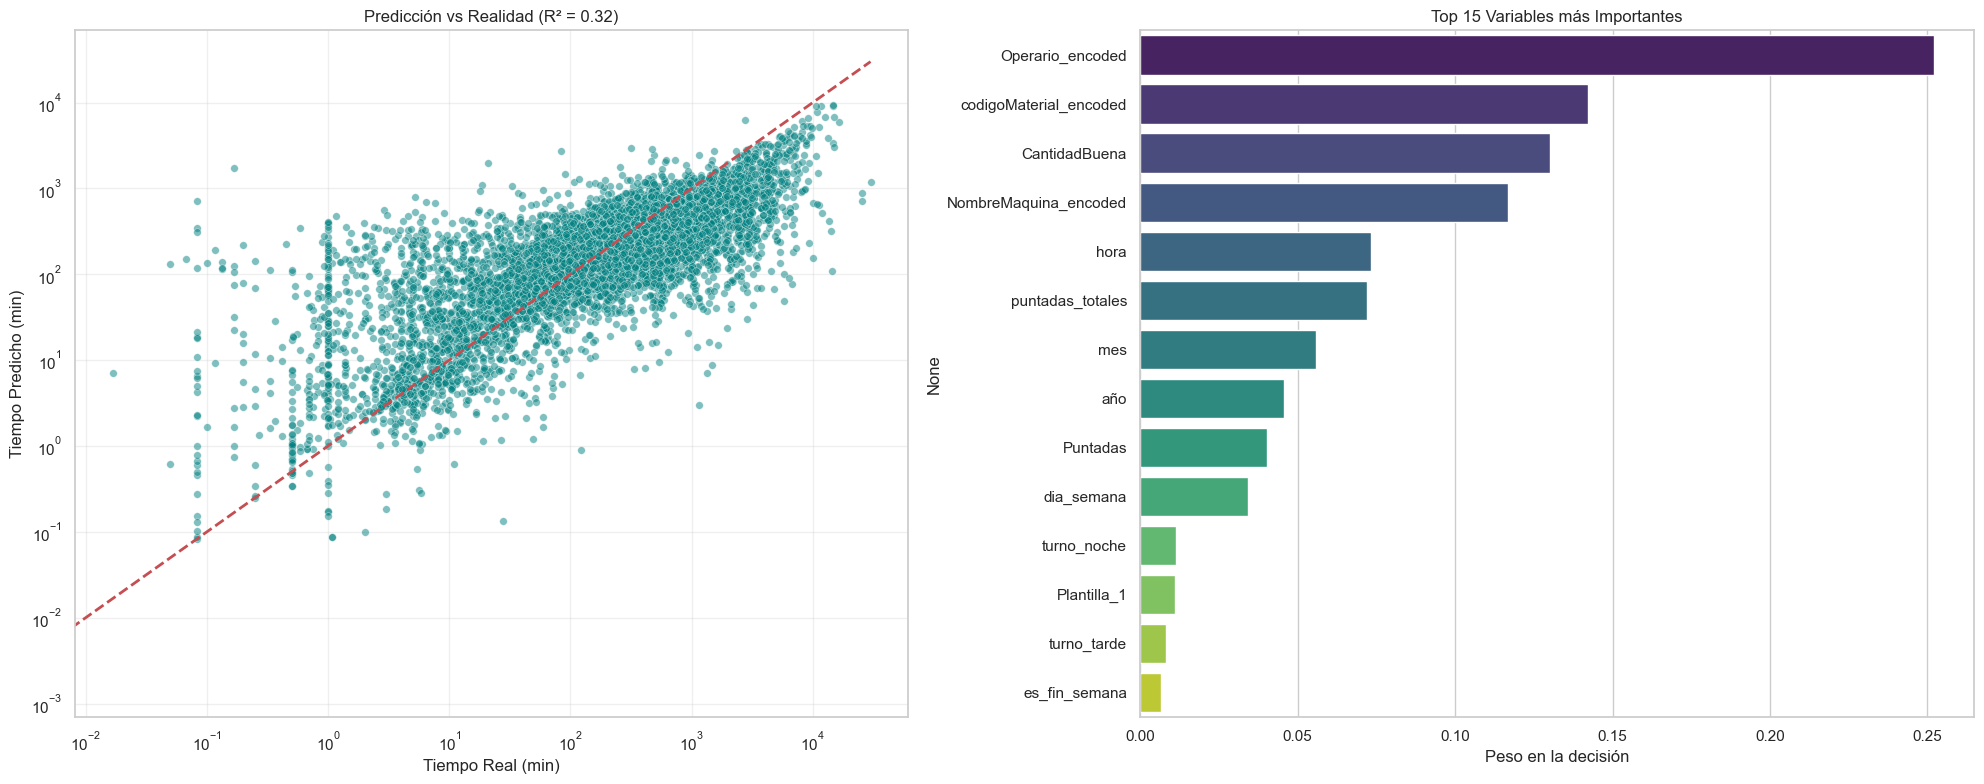

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# 1. RECONSTRUIR EL MODELO CAMPEÓN
# Usamos exactamente los parámetros que encontró tu búsqueda
champion_model = ExtraTreesRegressor(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    max_depth=30,
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)

print(" Entrenando al Modelo Campeón...")
# Asumiendo que y_train sigue en escala Log (si no, quita np.log1p)
champion_model.fit(X_train, np.log1p(y_train)) 

# 2. PREDECIR Y EVALUAR
y_pred_log = champion_model.predict(X_test)
y_pred = np.expm1(y_pred_log) # Volver a minutos reales

# Métricas Finales
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))


print(f"   • R²: {r2:.4f} (Explicamos el {r2*100:.1f}% del comportamiento)")
print(f"   • MAE: {mae:.0f} minutos (Error promedio de {(mae/60):.1f} horas)")
print(f"   • RMSE: {rmse:.0f} minutos")

# 3. GRÁFICAS DE HONOR
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# A. Predicción vs Realidad
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='teal', s=30, ax=axes[0])
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title(f'Predicción vs Realidad (R² = {r2:.2f})')
axes[0].set_xlabel('Tiempo Real (min)')
axes[0].set_ylabel('Tiempo Predicho (min)')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# B. Importancia de Variables (¿Qué mira el modelo?)
importances = champion_model.feature_importances_
indices = np.argsort(importances)[::-1][:15] # Top 15
cols = X_train.columns

sns.barplot(x=importances[indices], y=cols[indices], palette='viridis', ax=axes[1])
axes[1].set_title('Top 15 Variables más Importantes')
axes[1].set_xlabel('Peso en la decisión')

plt.tight_layout()
plt.show()

## analisis de importancia de caracteristicas



In [ ]:
def analyze_feature_importance(model, feature_names, top_n=20, title='Análisis de Importancia de Características'):
    """Analiza y visualiza la importancia de características de forma robusta."""
    # 1) Extraer importancias
    importances = None
    if hasattr(model, 'feature_importances_'):
        importances = np.asarray(model.feature_importances_, dtype=float)
    elif hasattr(model, 'coef_'):
        coef_ = np.asarray(model.coef_, dtype=float)
        # Multi-clase: promedio del valor absoluto por columna
        importances = np.mean(np.abs(coef_), axis=0) if coef_.ndim > 1 else np.abs(coef_)
    else:
        print("⚠️ El modelo no expone ni 'feature_importances_' ni 'coef_'.")
        return None

    # 2) Validar y alinear nombres de features
    if feature_names is None:
        feature_names = [f'Feature_{i}' for i in range(len(importances))]
    else:
        feature_names = list(feature_names)
        if len(feature_names) != len(importances):
            print(f"⚠️ Largo de 'feature_names' ({len(feature_names)}) ≠ largo de importancias ({len(importances)}). "
                  "Se generarán nombres genéricos.")
            feature_names = [f'Feature_{i}' for i in range(len(importances))]

    # 3) Armar DataFrame ordenado
    order = np.argsort(importances)[::-1]
    importance_df = pd.DataFrame({
        'Feature': [feature_names[i] for i in order],
        'Importance': importances[order]
    })

    # 4) Limitar a top_k existente para el gráfico de barras
    top_k = min(top_n, len(importance_df))
    top_df = importance_df.head(top_k)

    # 5) Visualización
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Barras horizontales (usa posiciones 0..top_k-1)
    y_pos = np.arange(top_k)
    ax1.barh(y_pos, top_df['Importance'].values)
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(top_df['Feature'].values)
    ax1.set_xlabel('Importancia')
    ax1.set_title(f'Top {top_k} características')
    ax1.invert_yaxis()

    # Gráfico de torta (usa hasta 10 o menos si no hay tantas)
    pie_k = min(10, len(importance_df))
    pie_df = importance_df.head(pie_k)
    other_importance = importance_df.iloc[pie_k:]['Importance'].sum()

    pie_data = pie_df['Importance'].tolist()
    pie_labels = pie_df['Feature'].tolist()
    if other_importance > 0:
        pie_data.append(other_importance)
        pie_labels.append('Otras')

    # Evitar error si todo es cero
    if np.sum(pie_data) == 0:
        ax2.text(0.5, 0.5, 'Sin variación en importancias', ha='center', va='center')
        ax2.axis('off')
    else:
        ax2.pie(pie_data, labels=pie_labels, autopct='%1.1f%%')
        ax2.set_title(f'Distribución de Importancia (Top {pie_k})')

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

    return importance_df



===== Importancia de características para: Extra Trees =====


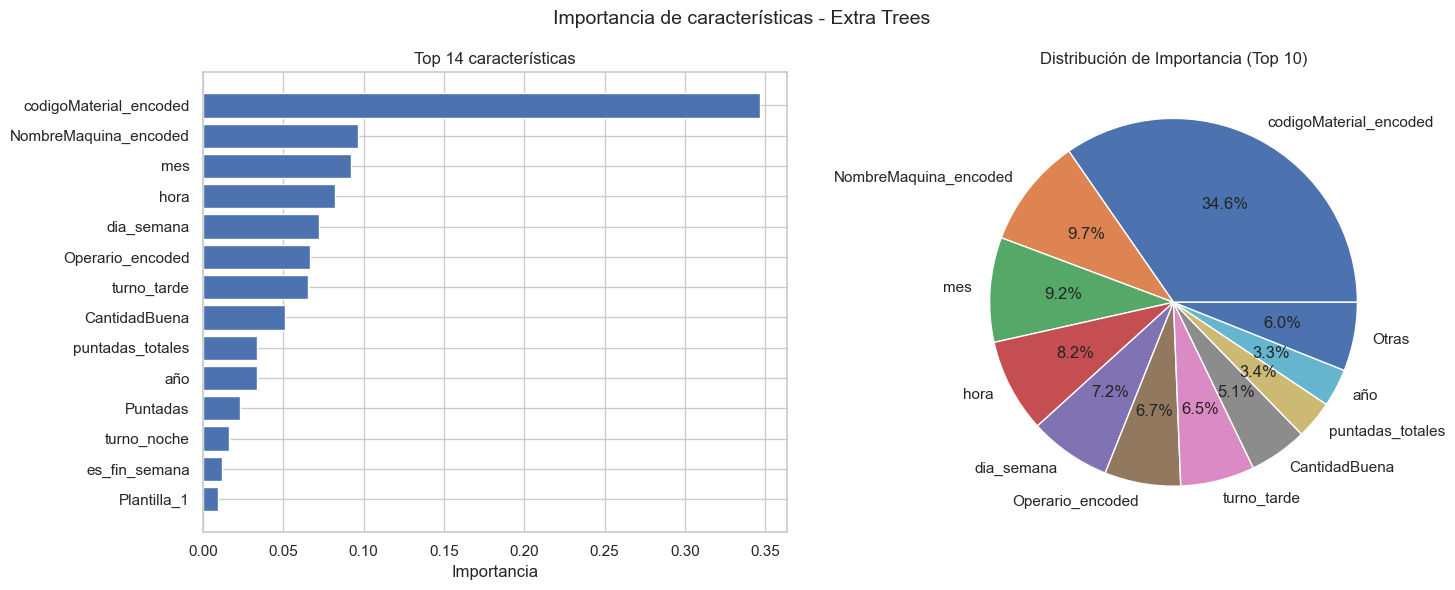


📊 TOP 10 características más importantes:


,Feature,Importance
0,codigoMaterial_encoded,0.35
1,NombreMaquina_encoded,0.10
2,mes,0.09
3,hora,0.08
4,dia_semana,0.07
5,Operario_encoded,0.07
6,turno_tarde,0.07
7,CantidadBuena,0.05
8,puntadas_totales,0.03
9,año,0.03



===== Importancia de características para: LightGBM =====


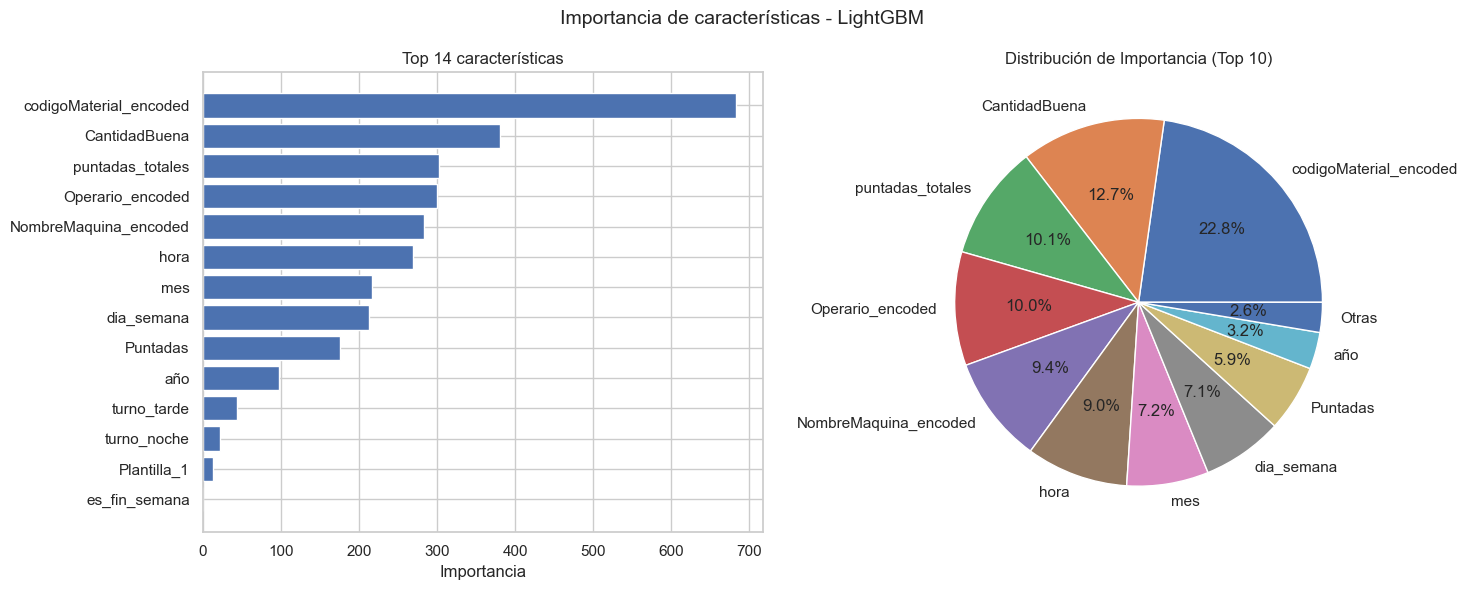


📊 TOP 10 características más importantes:


,Feature,Importance
0,codigoMaterial_encoded,683.00
1,CantidadBuena,381.00
2,puntadas_totales,303.00
3,Operario_encoded,300.00
4,NombreMaquina_encoded,283.00
5,hora,269.00
6,mes,216.00
7,dia_semana,213.00
8,Puntadas,176.00
9,año,97.00


In [ ]:
feature_names = X_train.columns
importances_dict = {}

for model_name in top2_model_names:
    # OJO: el nombre en results_df['Modelo'] debe coincidir
    # con la llave en el dict 'models'
    model = models[model_name]

    print(f"\n===== Importancia de características para: {model_name} =====")
    imp_df = analyze_feature_importance(
        model,
        feature_names,
        top_n=20,
        title=f"Importancia de características - {model_name}"
    )
    importances_dict[model_name] = imp_df

    if imp_df is not None:
        print("\n📊 TOP 10 características más importantes:")
        display(imp_df.head(10))

In [ ]:
from scipy import stats
import matplotlib.pyplot as plt

def analyze_residuals(y_true, y_pred):
    """Análisis completo de residuos"""
    
    residuals = y_true - y_pred
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # 1. Residuos vs Predicciones
    ax1 = axes[0, 0]
    ax1.scatter(y_pred, residuals, alpha=0.3, s=10)
    ax1.axhline(y=0, color='red', linestyle='--')
    ax1.set_xlabel('Valores Predichos')
    ax1.set_ylabel('Residuos')
    ax1.set_title('Residuos vs Predicciones')
    ax1.grid(True, alpha=0.3)
    
    # 2. Distribución de residuos
    ax2 = axes[0, 1]
    ax2.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
    ax2.axvline(x=0, color='red', linestyle='--')
    ax2.set_xlabel('Residuos')
    ax2.set_ylabel('Frecuencia')
    ax2.set_title('Distribución de Residuos')
    ax2.grid(True, alpha=0.3)
    
    # 3. Q-Q Plot
    ax3 = axes[0, 2]
    stats.probplot(residuals, dist="norm", plot=ax3)
    ax3.set_title('Q-Q Plot de Residuos')
    ax3.grid(True, alpha=0.3)
    
    # 4. Valores reales vs predichos
    ax4 = axes[1, 0]
    ax4.scatter(y_true, y_pred, alpha=0.3, s=10)
    ax4.plot([y_true.min(), y_true.max()], 
             [y_true.min(), y_true.max()], 
             'r--', lw=2)
    ax4.set_xlabel('Valores Reales')
    ax4.set_ylabel('Valores Predichos')
    ax4.set_title('Reales vs Predichos')
    ax4.grid(True, alpha=0.3)
    
    # 5. Residuos estandarizados
    ax5 = axes[1, 1]
    if residuals.std() > 0:
        standardized_residuals = residuals / residuals.std()
    else:
        standardized_residuals = residuals
    
    ax5.scatter(y_pred, standardized_residuals, alpha=0.3, s=10)
    ax5.axhline(y=0, color='red', linestyle='--')
    ax5.axhline(y=2, color='orange', linestyle='--', alpha=0.5)
    ax5.axhline(y=-2, color='orange', linestyle='--', alpha=0.5)
    ax5.set_xlabel('Valores Predichos')
    ax5.set_ylabel('Residuos Estandarizados')
    ax5.set_title('Residuos Estandarizados')
    ax5.grid(True, alpha=0.3)
    
    # 6. Estadísticas de residuos
    ax6 = axes[1, 2]
    ax6.axis('off')
    
    # Shapiro con máximo 5000 observaciones
    n_shapiro = min(len(residuals), 5000)
    shapiro_p = stats.shapiro(residuals[:n_shapiro])[1] if n_shapiro >= 3 else np.nan
    
    residual_stats = f"""
    Estadísticas de Residuos:
    
    • Media: {residuals.mean():,.2f}
    • Mediana: {residuals.median():,.2f}
    • Desv. Est.: {residuals.std():,.2f}
    • Mín: {residuals.min():,.2f}
    • Máx: {residuals.max():,.2f}
    • Asimetría: {stats.skew(residuals):.2f}
    • Curtosis: {stats.kurtosis(residuals):.2f}
    
    Prueba de Normalidad (Shapiro-Wilk, n={n_shapiro}):
    p-valor: {shapiro_p:.4f}
    """
    
    ax6.text(0.05, 0.5, residual_stats, transform=ax6.transAxes,
             fontsize=11, verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='lightblue'))
    
    plt.suptitle('Análisis de Residuos del Modelo', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()



🧪 Análisis para modelo: Extra Trees
   R² Test : 0.4367
   RMSE    : 883.34
   MAE     : 368.79
   MAPE    : 3065.70%


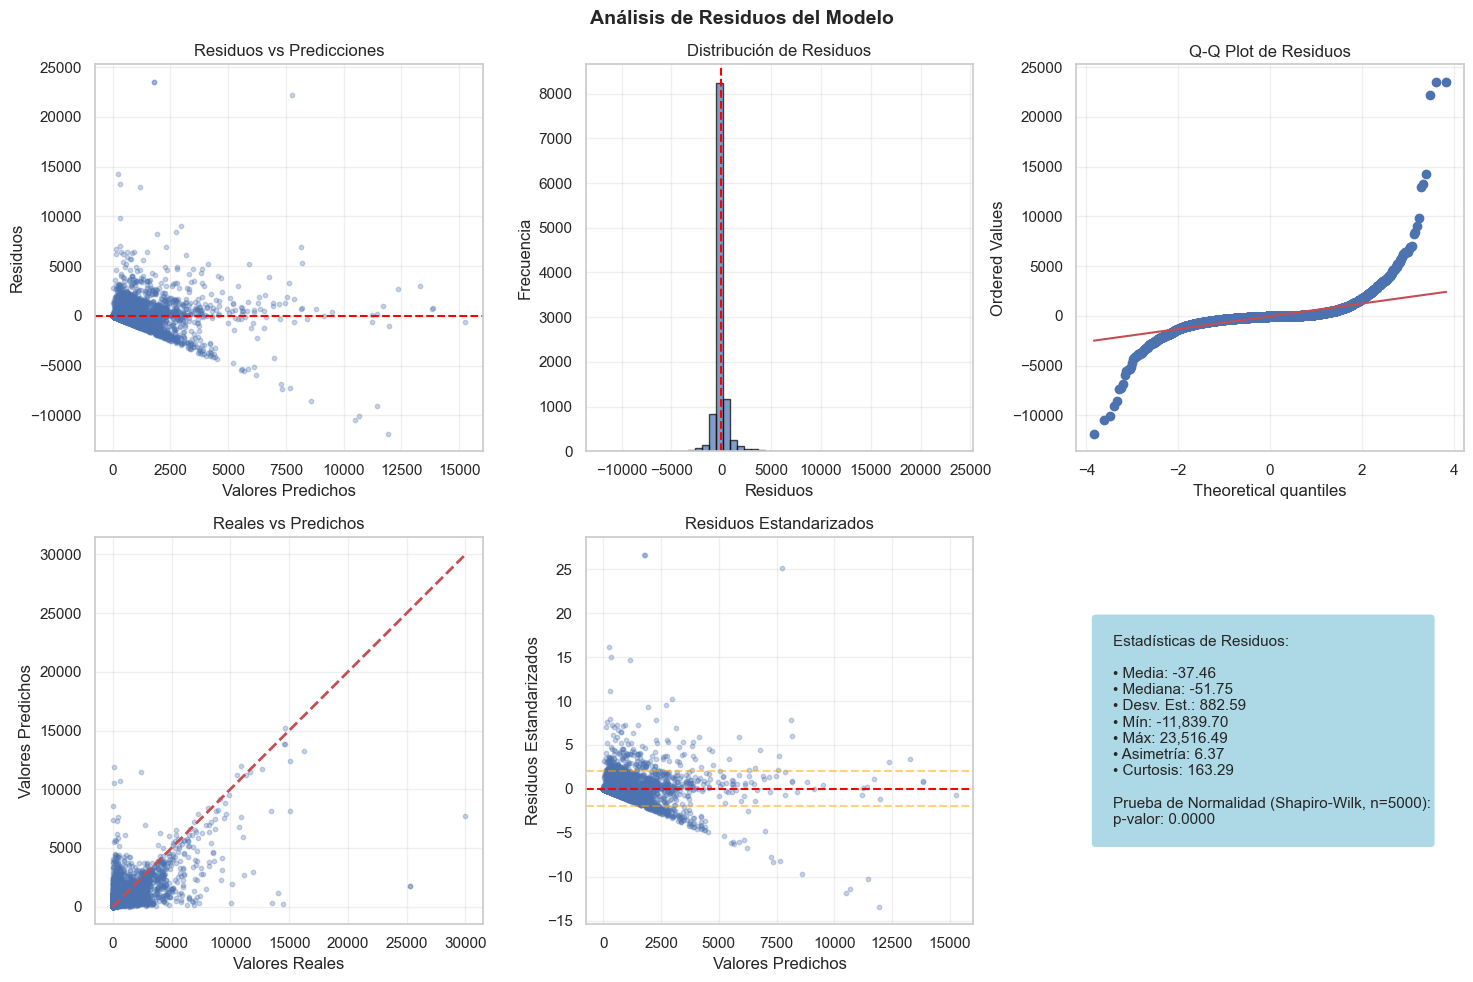


🧪 Análisis para modelo: LightGBM
   R² Test : 0.2121
   RMSE    : 1044.69
   MAE     : 421.19
   MAPE    : 3142.01%


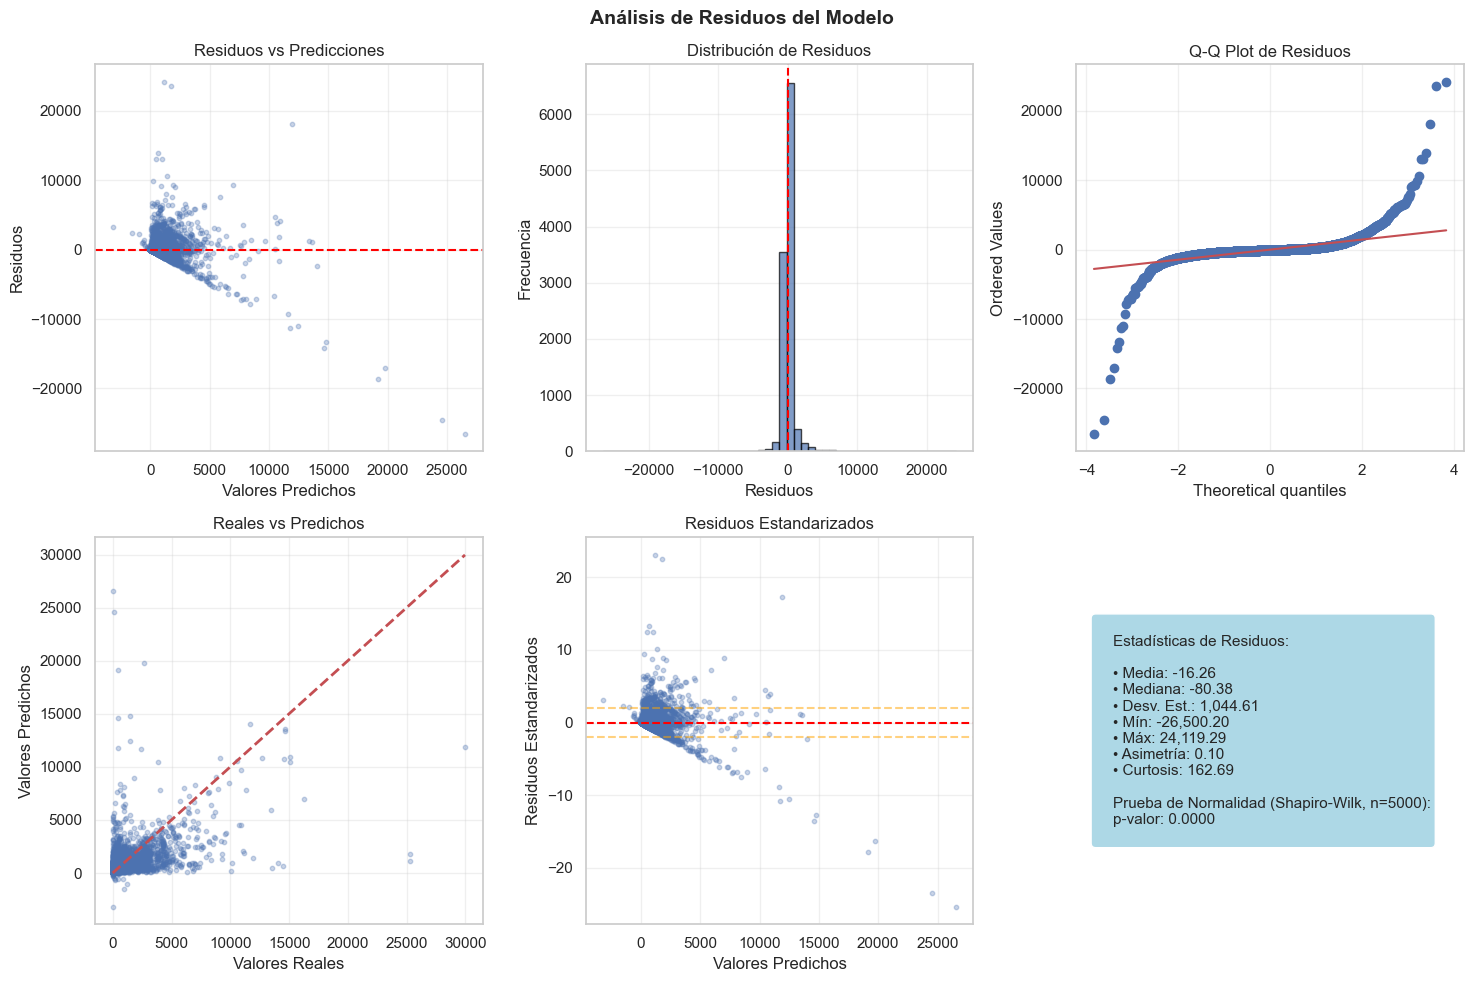

In [ ]:
for name in top2_model_names:
    print("\n" + "="*60)
    print(f"🧪 Análisis para modelo: {name}")
    
    model = models[name]  # el modelo ya está entrenado por tu loop anterior
    
    # Predicciones en test
    y_pred_test = model.predict(X_test)
    
    # Métricas
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mae_test = mean_absolute_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)
    
    # MAPE robusto (evitar división por cero)
    y_test_safe = y_test.copy()
    mask_nonzero = y_test_safe != 0
    if mask_nonzero.any():
        mape_test = np.mean(
            np.abs((y_test_safe[mask_nonzero] - y_pred_test[mask_nonzero]) / y_test_safe[mask_nonzero])
        ) * 100
    else:
        mape_test = np.nan
    
    print(f"   R² Test : {r2_test:.4f}")
    print(f"   RMSE    : {rmse_test:.2f}")
    print(f"   MAE     : {mae_test:.2f}")
    print(f"   MAPE    : {mape_test:.2f}%")
    
    # 🔍 Análisis de residuos
    analyze_residuals(y_test, y_pred_test)

In [ ]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def calculate_confidence_intervals(model, X, confidence=0.95):
    """
    Calcula intervalos de confianza para las predicciones.
    Aproximación tipo ensemble: usa la variabilidad entre árboles.
    Solo funciona si el modelo tiene atributo estimators_ (RandomForest, ExtraTrees, etc.)
    """
    if not hasattr(model, 'estimators_'):
        # Sin prints para no ensuciar
        return None, None, None

    # 🔹 Asegurar que X sea un array, NO un DataFrame con nombres
    if isinstance(X, pd.DataFrame):
        X_input = X.values
    else:
        X_input = X

    # Predicción de cada árbol
    predictions = np.array([tree.predict(X_input) for tree in model.estimators_])
    mean_pred = predictions.mean(axis=0)
    std_pred = predictions.std(axis=0)

    # z para el nivel de confianza
    z_score = stats.norm.ppf((1 + confidence) / 2)
    lower_bound = mean_pred - z_score * std_pred
    upper_bound = mean_pred + z_score * std_pred

    return mean_pred, lower_bound, upper_bound




🎯 Intervalos de confianza para: Extra Trees


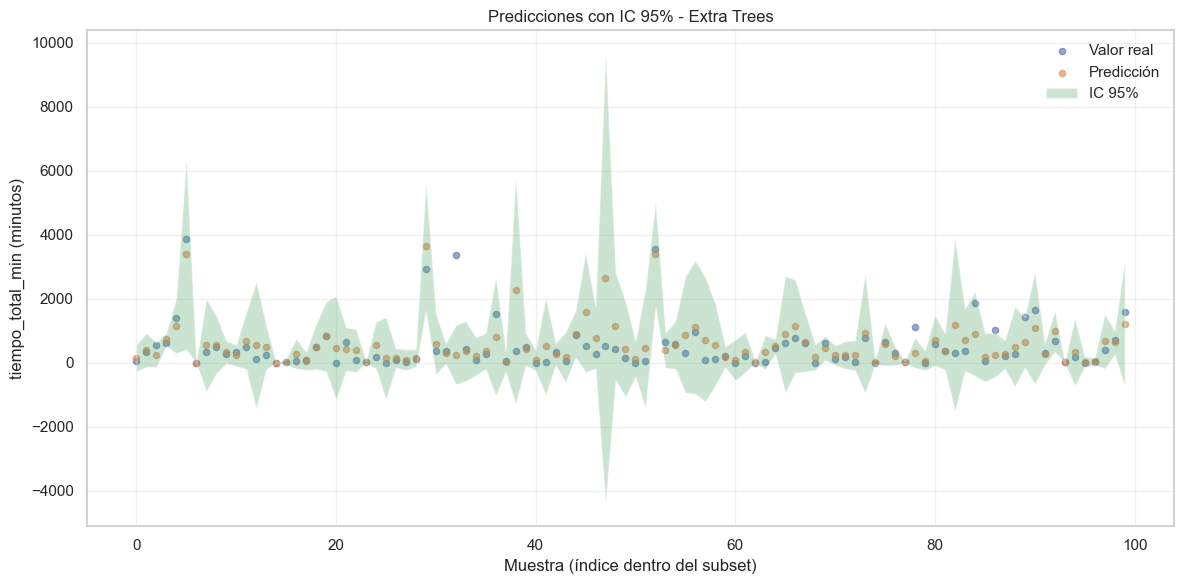

📊 Cobertura de los intervalos de confianza: 95.0%

🎯 Intervalos de confianza para: LightGBM


In [ ]:
# Tomar una muestra aleatoria del conjunto de prueba
sample_size = min(100, len(X_test))  # por si el test es pequeño
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), sample_size, replace=False)

# Soportar X_test como DataFrame o array
if isinstance(X_test, pd.DataFrame):
    X_sample = X_test.iloc[sample_indices]
else:
    X_sample = X_test[sample_indices]

y_sample = y_test.iloc[sample_indices]

# =========================================================
# 3) Calcular y graficar IC para cada modelo del top 2
# =========================================================
for model_name in top2_model_names:
    print("\n" + "="*70)
    print(f"🎯 Intervalos de confianza para: {model_name}")
    
    model = models[model_name]  # modelo ya entrenado en tu loop previo
    
    mean_pred, lower_bound, upper_bound = calculate_confidence_intervals(
        model, X_sample  # usamos el mismo subset para comparar
    )
    
    # Si el modelo no tiene estimators_ (por ejemplo, CatBoost, LGBM, lineales), se salta
    if mean_pred is None:
        continue
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    indices = np.arange(sample_size)
    ax.scatter(indices, y_sample, label='Valor real', alpha=0.6, s=20)
    ax.scatter(indices, mean_pred, label='Predicción', alpha=0.6, s=20)
    ax.fill_between(indices, lower_bound, upper_bound,
                    alpha=0.3, label='IC 95%')
    
    ax.set_xlabel('Muestra (índice dentro del subset)')
    ax.set_ylabel('tiempo_total_min (minutos)')
    ax.set_title(f'Predicciones con IC 95% - {model_name}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Cobertura del intervalo
    coverage = np.mean((y_sample >= lower_bound) & (y_sample <= upper_bound))
    print(f"📊 Cobertura de los intervalos de confianza: {coverage:.1%}")
